# Лабораторная работа №3

## Классификация временных рядов и прогнозирование на примере метеоданных шести городов России

**Цель:** реализовать двухэтапную систему анализа метеорологических временных рядов.

1. **Классификация:** по временному ряду метеопараметров определить климатический тип наблюдаемого окна.
2. **Прогнозирование:** для каждого города построить отдельную модель прогноза температуры на горизонтах 1–30 дней.

**Города:** Москва, Сочи, Благовещенск, Находка, Геленджик, Санкт-Петербург.  
**Период:** 2019–2025.  
**Источник данных:** Open-Meteo.

Ожидаемая структура файлов:

```text
data/
├── Москва_2019-01-01_2019-12-31.parquet
├── Москва_2020-01-01_2020-12-31.parquet
├── ...
└── Санкт-Петербург_2025-01-01_2025-12-31.parquet
```

Дата/время может находиться либо в индексе parquet-файла, либо в колонке `time`, `date` или `datetime`.

## 0. Установка зависимостей и импорты

In [ ]:

!pip install pandas numpy matplotlib seaborn scipy statsmodels scikit-learn sktime lightgbm shap pyarrow fastparquet tqdm nbformat ipykernel



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro, probplot
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox, het_white

from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    mean_absolute_error,
    mean_squared_error,
    f1_score,
    ConfusionMatrixDisplay,
)
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.multioutput import MultiOutputRegressor

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except Exception as exc:
    lgb = None
    LIGHTGBM_AVAILABLE = False
    print(f"LightGBM недоступен, для прогноза будет использован HistGradientBoostingRegressor: {exc}")

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.figsize": (14, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.family": "DejaVu Sans",
})

print("Зависимости загружены")


Зависимости загружены


## 1. Загрузка данных

In [3]:
DATA_DIR = Path("/Users/maksimtimosuk/Downloads/drive-download-20260511T194333Z-3-001")

CITIES = [
    "Москва",
    "Сочи",
    "Благовещенск",
    "Находка",
    "Геленджик",
    "Санкт-Петербург",
]

YEARS = list(range(2019, 2026))

FEATURES = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "rain",
    "snowfall",
    "weathercode",
    "wind_speed_10m",
    "surface_pressure",
]

TARGET = "temperature_2m"


def ensure_datetime_index(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
        return df.sort_index()

    for col in ["time", "date", "datetime", "Дата", "Время"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
            df = df.dropna(subset=[col]).set_index(col)
            return df.sort_index()

    raise ValueError("Не найден индекс даты/времени или колонка time/date/datetime.")


def load_city_data(city: str, data_dir: Path = DATA_DIR) -> pd.DataFrame:
    frames = []

    for year in YEARS:
        file_name = f"{city}_{year}-01-01_{year}-12-31.parquet"
        files = sorted(data_dir.glob(file_name))

        if not files:
            print(f"  Файл не найден: {file_name}")
            continue

        df = pd.read_parquet(files[0])
        df = ensure_datetime_index(df)

        existing_cols = [c for c in FEATURES if c in df.columns]
        if TARGET not in existing_cols:
            raise ValueError(f"В файле {file_name} нет колонки {TARGET}.")

        frames.append(df[existing_cols])

    if not frames:
        raise FileNotFoundError(f"Нет данных для города: {city}")

    result = pd.concat(frames).sort_index()
    result = result[~result.index.duplicated(keep="first")]
    return result


print("Загрузка данных...")

city_data = {}

for city in CITIES:
    try:
        city_data[city] = load_city_data(city)
        df = city_data[city]
        print(
            f"  {city}: {len(df)} строк, "
            f"{df.index.min().date()} — {df.index.max().date()}"
        )
    except Exception as exc:
        print(f"  {city}: {exc}")

loaded_cities = list(city_data.keys())

if not loaded_cities:
    raise RuntimeError("Не загружен ни один город. Проверьте DATA_DIR и имена parquet-файлов.")

print(f"\nЗагружено городов: {len(loaded_cities)}")

Загрузка данных...
  Москва: 61368 строк, 2019-01-01 — 2025-12-31
  Сочи: 61368 строк, 2019-01-01 — 2025-12-31
  Благовещенск: 61368 строк, 2019-01-01 — 2025-12-31
  Находка: 61368 строк, 2019-01-01 — 2025-12-31
  Геленджик: 61368 строк, 2019-01-01 — 2025-12-31
  Санкт-Петербург: 61368 строк, 2019-01-01 — 2025-12-31

Загружено городов: 6


In [4]:
CLIMATE_GROUPS = {
    "Москва": "умеренно-континентальный",
    "Санкт-Петербург": "умеренно-континентальный",
    "Сочи": "черноморский",
    "Геленджик": "черноморский",
    "Благовещенск": "дальневосточный",
    "Находка": "дальневосточный",
}

missing_groups = [city for city in loaded_cities if city not in CLIMATE_GROUPS]
if missing_groups:
    raise ValueError(f"Для городов не задан тип климата: {missing_groups}")

climate_group_counts = pd.Series({city: CLIMATE_GROUPS[city] for city in loaded_cities}).value_counts()
print("Климатические группы:")
display(pd.DataFrame({"Тип климата": climate_group_counts.index, "Количество городов": climate_group_counts.values}))

if (climate_group_counts < 2).any():
    raise ValueError("По условию задания в каждом типе климата должно быть минимум два города.")

Климатические группы:


,Тип климата,Количество городов
0,умеренно-континентальный,2
1,черноморский,2
2,дальневосточный,2


In [5]:
sample_city = loaded_cities[0]

print(f"Пример данных: {sample_city}")
display(city_data[sample_city].head())

print("\nТипы данных:")
display(city_data[sample_city].dtypes.to_frame("dtype"))

print("\nПропуски, %:")
display((city_data[sample_city].isna().mean() * 100).round(2).to_frame("missing_%"))

Пример данных: Москва


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure
time,,,,,,,,
2019-01-01 00:00:00,-6.5000,92,0.0000,0.0000,0.0000,3,10.8000,1000.5000
2019-01-01 01:00:00,-6.8000,92,0.0000,0.0000,0.0000,3,10.5000,1000.3000
2019-01-01 02:00:00,-6.8000,92,0.0000,0.0000,0.0000,3,10.8000,1000.0000
2019-01-01 03:00:00,-5.8000,93,0.0000,0.0000,0.0000,3,12.2000,999.3000
2019-01-01 04:00:00,-5.9000,93,0.0000,0.0000,0.0000,3,14.4000,998.6000



Типы данных:


,dtype
temperature_2m,float32
relative_humidity_2m,int64
precipitation,float32
rain,float32
snowfall,float32
weathercode,int64
wind_speed_10m,float32
surface_pressure,float32



Пропуски, %:


,missing_%
temperature_2m,0.0000
relative_humidity_2m,0.0000
precipitation,0.0000
rain,0.0000
snowfall,0.0000
weathercode,0.0000
wind_speed_10m,0.0000
surface_pressure,0.0000


## 2. Приведение к суточной частоте и обработка пропусков

In [6]:
def infer_is_hourly(df: pd.DataFrame) -> bool:
    if len(df) < 3:
        return False

    deltas = df.index.to_series().diff().dropna()
    if deltas.empty:
        return False

    return deltas.median() <= pd.Timedelta(hours=2)


def mode_or_nan(x: pd.Series):
    mode_values = x.mode(dropna=True)
    return mode_values.iloc[0] if len(mode_values) else np.nan


def resample_daily(df: pd.DataFrame) -> pd.DataFrame:
    agg = {
        "temperature_2m": "mean",
        "relative_humidity_2m": "mean",
        "precipitation": "sum",
        "rain": "sum",
        "snowfall": "sum",
        "weathercode": mode_or_nan,
        "wind_speed_10m": "max",
        "surface_pressure": "mean",
    }

    agg = {col: func for col, func in agg.items() if col in df.columns}
    return df.resample("D").agg(agg)


def fill_missing(df: pd.DataFrame, limit: int = 7) -> pd.DataFrame:
    df = df.sort_index()
    df = df.interpolate(method="time", limit=limit)
    df = df.ffill().bfill()
    return df


city_daily = {}

for city, df in city_data.items():
    if infer_is_hourly(df):
        daily = resample_daily(df)
        print(f"{city}: почасовые данные преобразованы в суточные, дней: {len(daily)}")
    else:
        daily = df.resample("D").mean(numeric_only=True)
        print(f"{city}: данные приведены к суточной частоте, дней: {len(daily)}")

    city_daily[city] = fill_missing(daily)

missing_after = {city: int(df.isna().sum().sum()) for city, df in city_daily.items()}
print("\nОставшиеся пропуски:", missing_after)

Москва: почасовые данные преобразованы в суточные, дней: 2557
Сочи: почасовые данные преобразованы в суточные, дней: 2557
Благовещенск: почасовые данные преобразованы в суточные, дней: 2557
Находка: почасовые данные преобразованы в суточные, дней: 2557
Геленджик: почасовые данные преобразованы в суточные, дней: 2557
Санкт-Петербург: почасовые данные преобразованы в суточные, дней: 2557

Оставшиеся пропуски: {'Москва': 0, 'Сочи': 0, 'Благовещенск': 0, 'Находка': 0, 'Геленджик': 0, 'Санкт-Петербург': 0}


## 3. Разведочный анализ данных

### 3.1. Пропуски

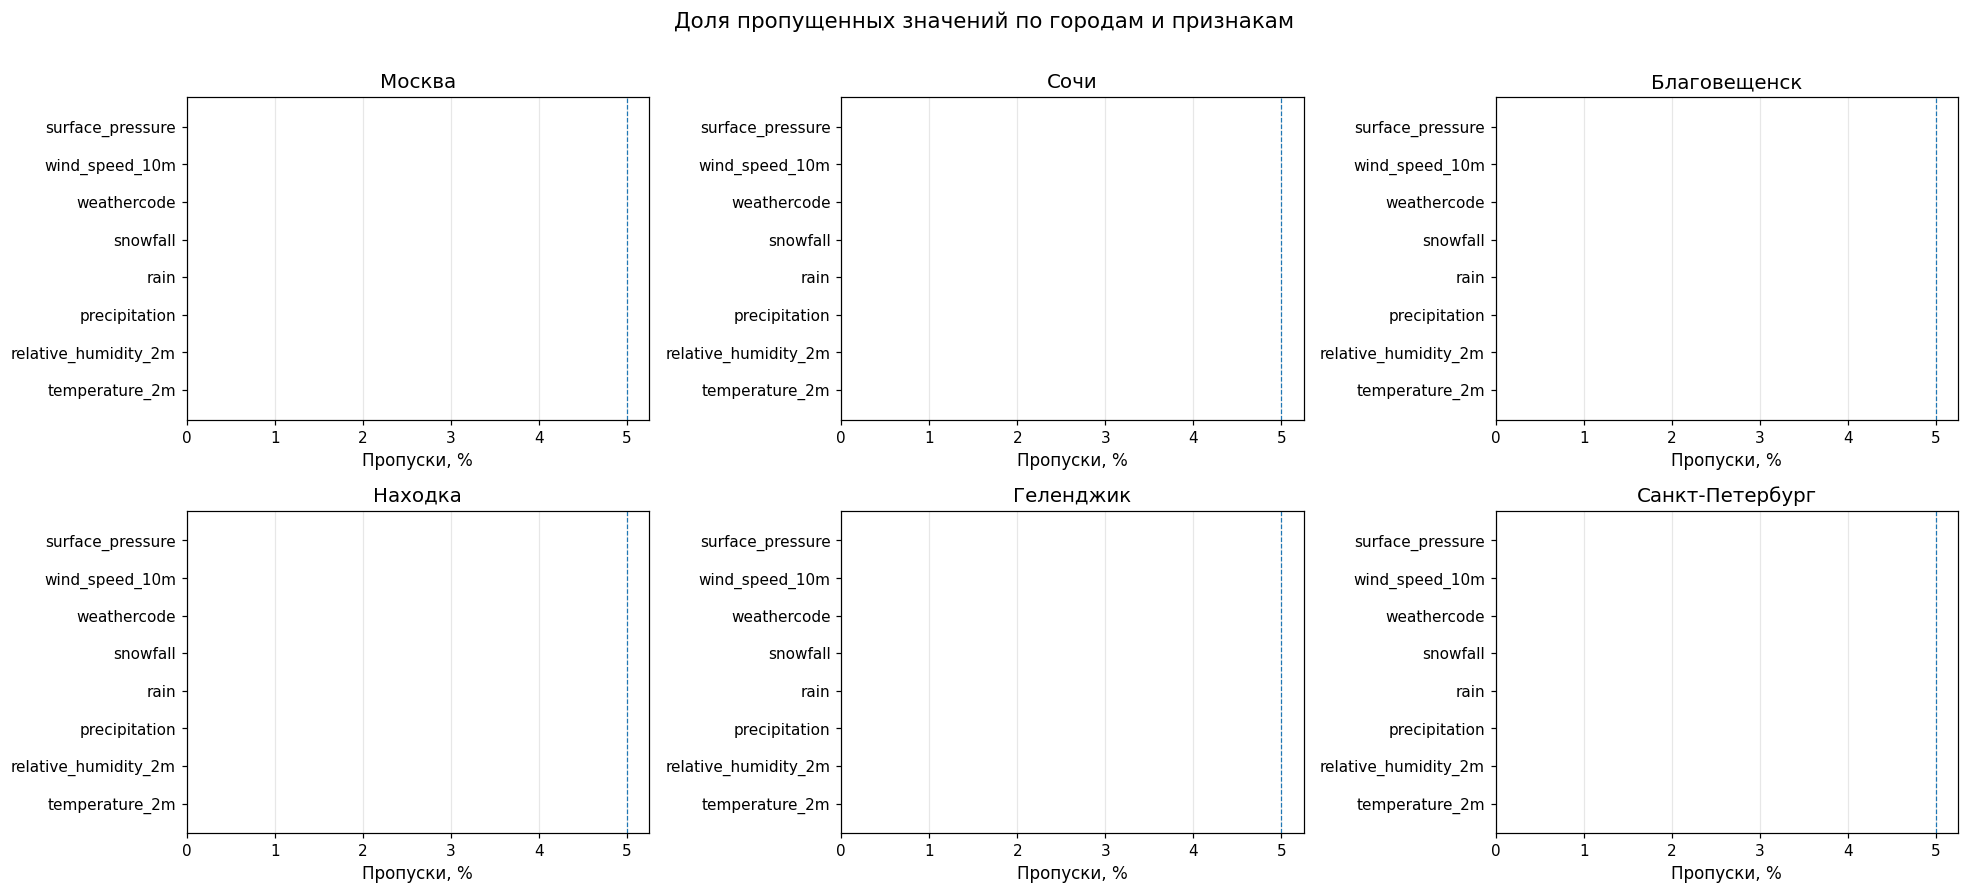

In [7]:
n = len(city_daily)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axes = np.array(axes).reshape(-1)

for ax in axes[n:]:
    ax.axis("off")

for ax, (city, df) in zip(axes, city_daily.items()):
    miss = df.isna().mean() * 100
    ax.barh(miss.index, miss.values)
    ax.set_title(city)
    ax.set_xlabel("Пропуски, %")
    ax.axvline(5, linestyle="--", linewidth=0.8)
    ax.grid(axis="x", alpha=0.3)

plt.suptitle("Доля пропущенных значений по городам и признакам", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 3.2. Температурные ряды

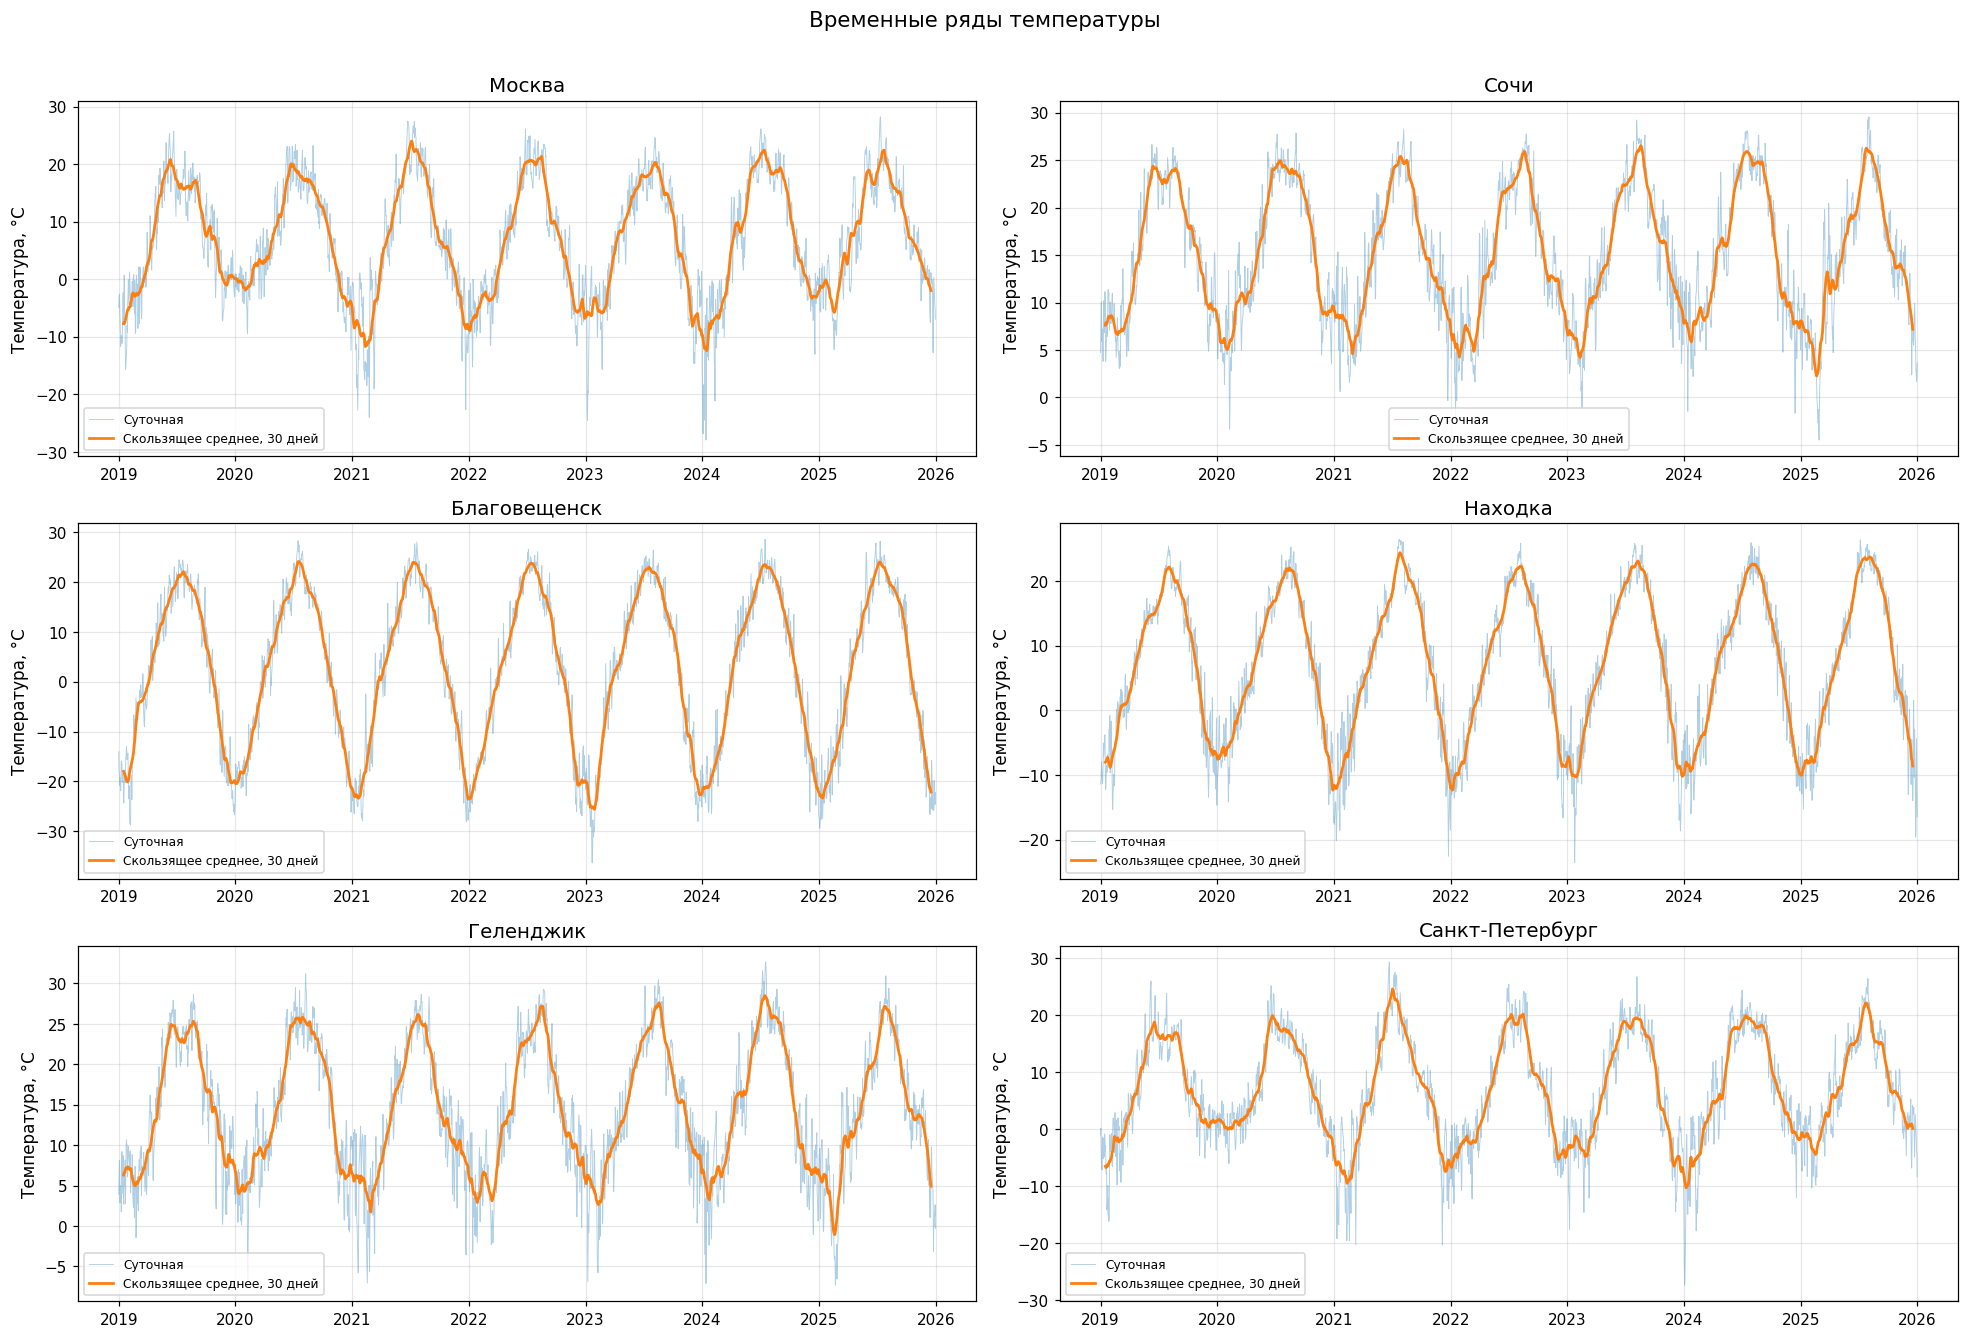

In [8]:
n = len(city_daily)
cols = 2
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(9 * cols, 4 * rows))
axes = np.array(axes).reshape(-1)

for ax in axes[n:]:
    ax.axis("off")

for ax, (city, df) in zip(axes, city_daily.items()):
    rolling_mean = df[TARGET].rolling(30, center=True).mean()
    ax.plot(df.index, df[TARGET], alpha=0.35, linewidth=0.6, label="Суточная")
    ax.plot(df.index, rolling_mean, linewidth=1.8, label="Скользящее среднее, 30 дней")
    ax.set_title(city)
    ax.set_ylabel("Температура, °C")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Временные ряды температуры", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 3.3. Распределения и климатические профили

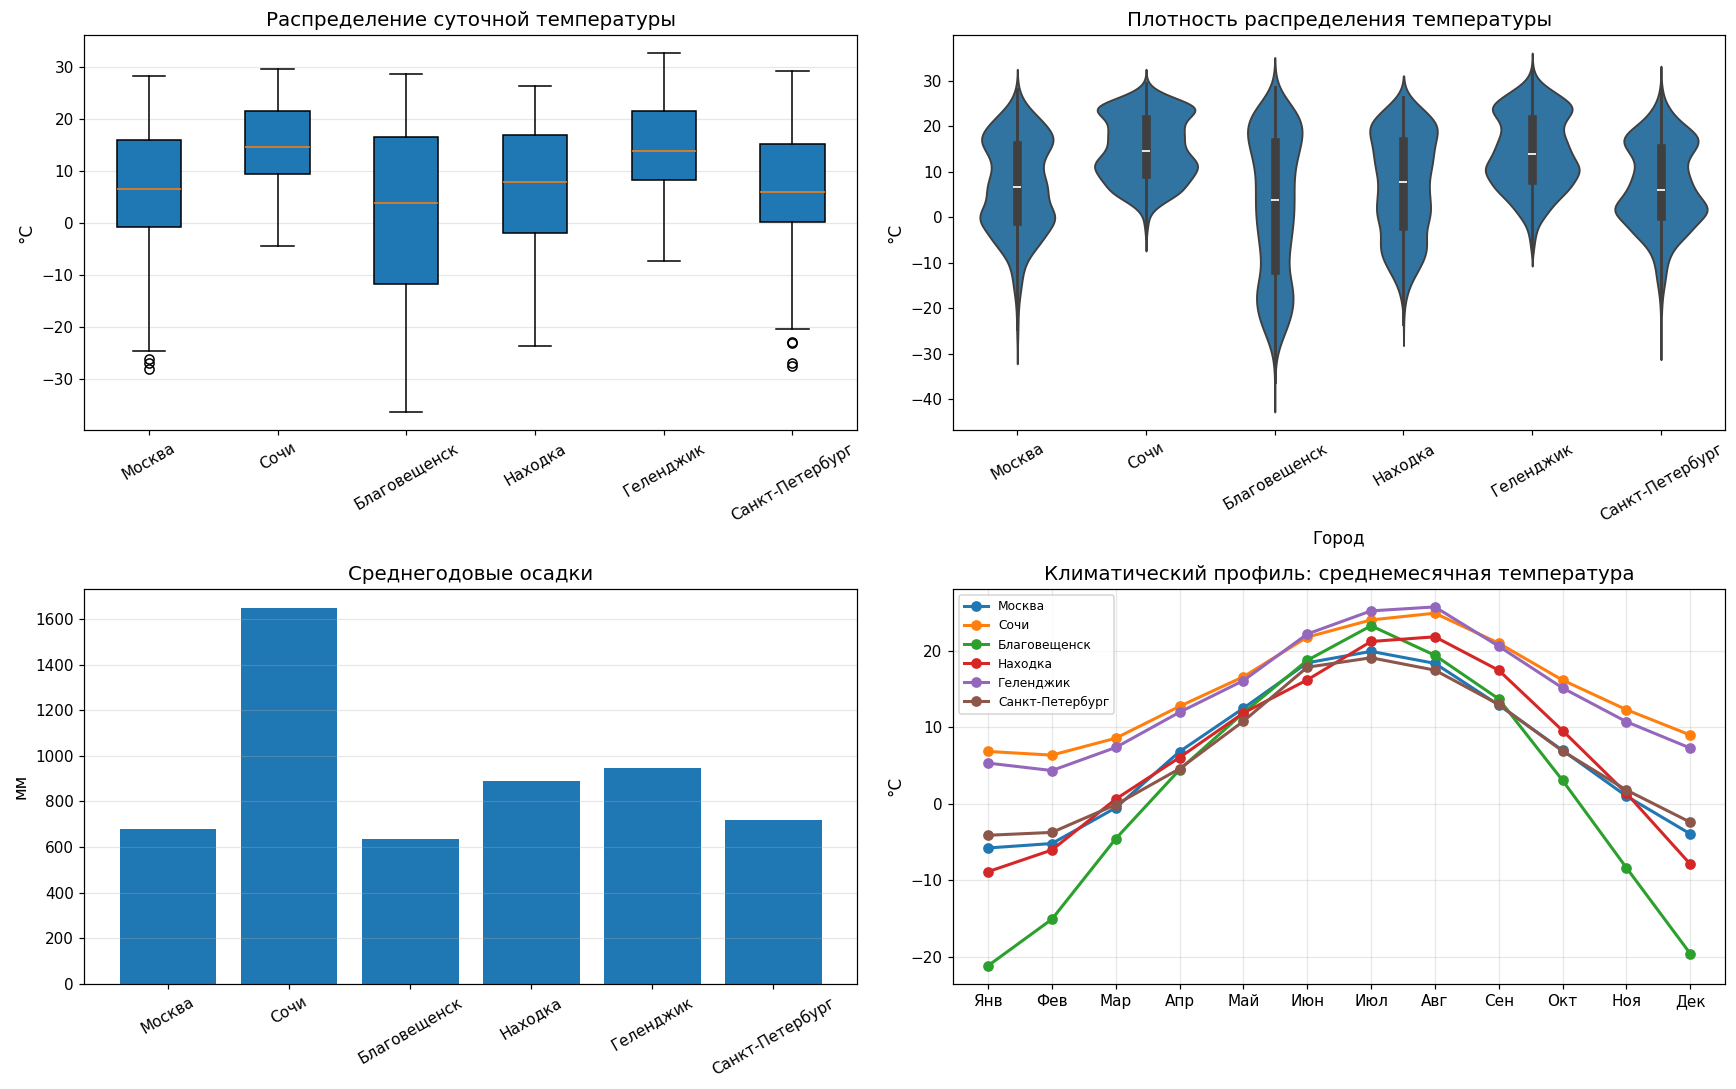

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

data_temp = [df[TARGET].dropna().values for df in city_daily.values()]
axes[0, 0].boxplot(data_temp, labels=list(city_daily.keys()), patch_artist=True)
axes[0, 0].set_title("Распределение суточной температуры")
axes[0, 0].set_ylabel("°C")
axes[0, 0].tick_params(axis="x", rotation=30)
axes[0, 0].grid(axis="y", alpha=0.3)

plot_df = pd.concat(
    [df[[TARGET]].assign(Город=city) for city, df in city_daily.items()],
    axis=0,
).dropna()

sns.violinplot(data=plot_df, x="Город", y=TARGET, ax=axes[0, 1])
axes[0, 1].set_title("Плотность распределения температуры")
axes[0, 1].tick_params(axis="x", rotation=30)
axes[0, 1].set_ylabel("°C")

annual_precip = {
    city: df["precipitation"].resample("YE").sum().mean()
    for city, df in city_daily.items()
    if "precipitation" in df.columns
}

if annual_precip:
    axes[1, 0].bar(annual_precip.keys(), annual_precip.values())
    axes[1, 0].set_title("Среднегодовые осадки")
    axes[1, 0].set_ylabel("мм")
    axes[1, 0].tick_params(axis="x", rotation=30)
    axes[1, 0].grid(axis="y", alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, "Нет колонки precipitation", ha="center", va="center")
    axes[1, 0].axis("off")

month_names = ["Янв", "Фев", "Мар", "Апр", "Май", "Июн", "Июл", "Авг", "Сен", "Окт", "Ноя", "Дек"]

for city, df in city_daily.items():
    monthly = df[TARGET].groupby(df.index.month).mean()
    axes[1, 1].plot(range(1, 13), monthly.reindex(range(1, 13)), marker="o", linewidth=2, label=city)

axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].set_xticklabels(month_names)
axes[1, 1].set_title("Климатический профиль: среднемесячная температура")
axes[1, 1].set_ylabel("°C")
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.4. Q-Q plots для проверки нормальности

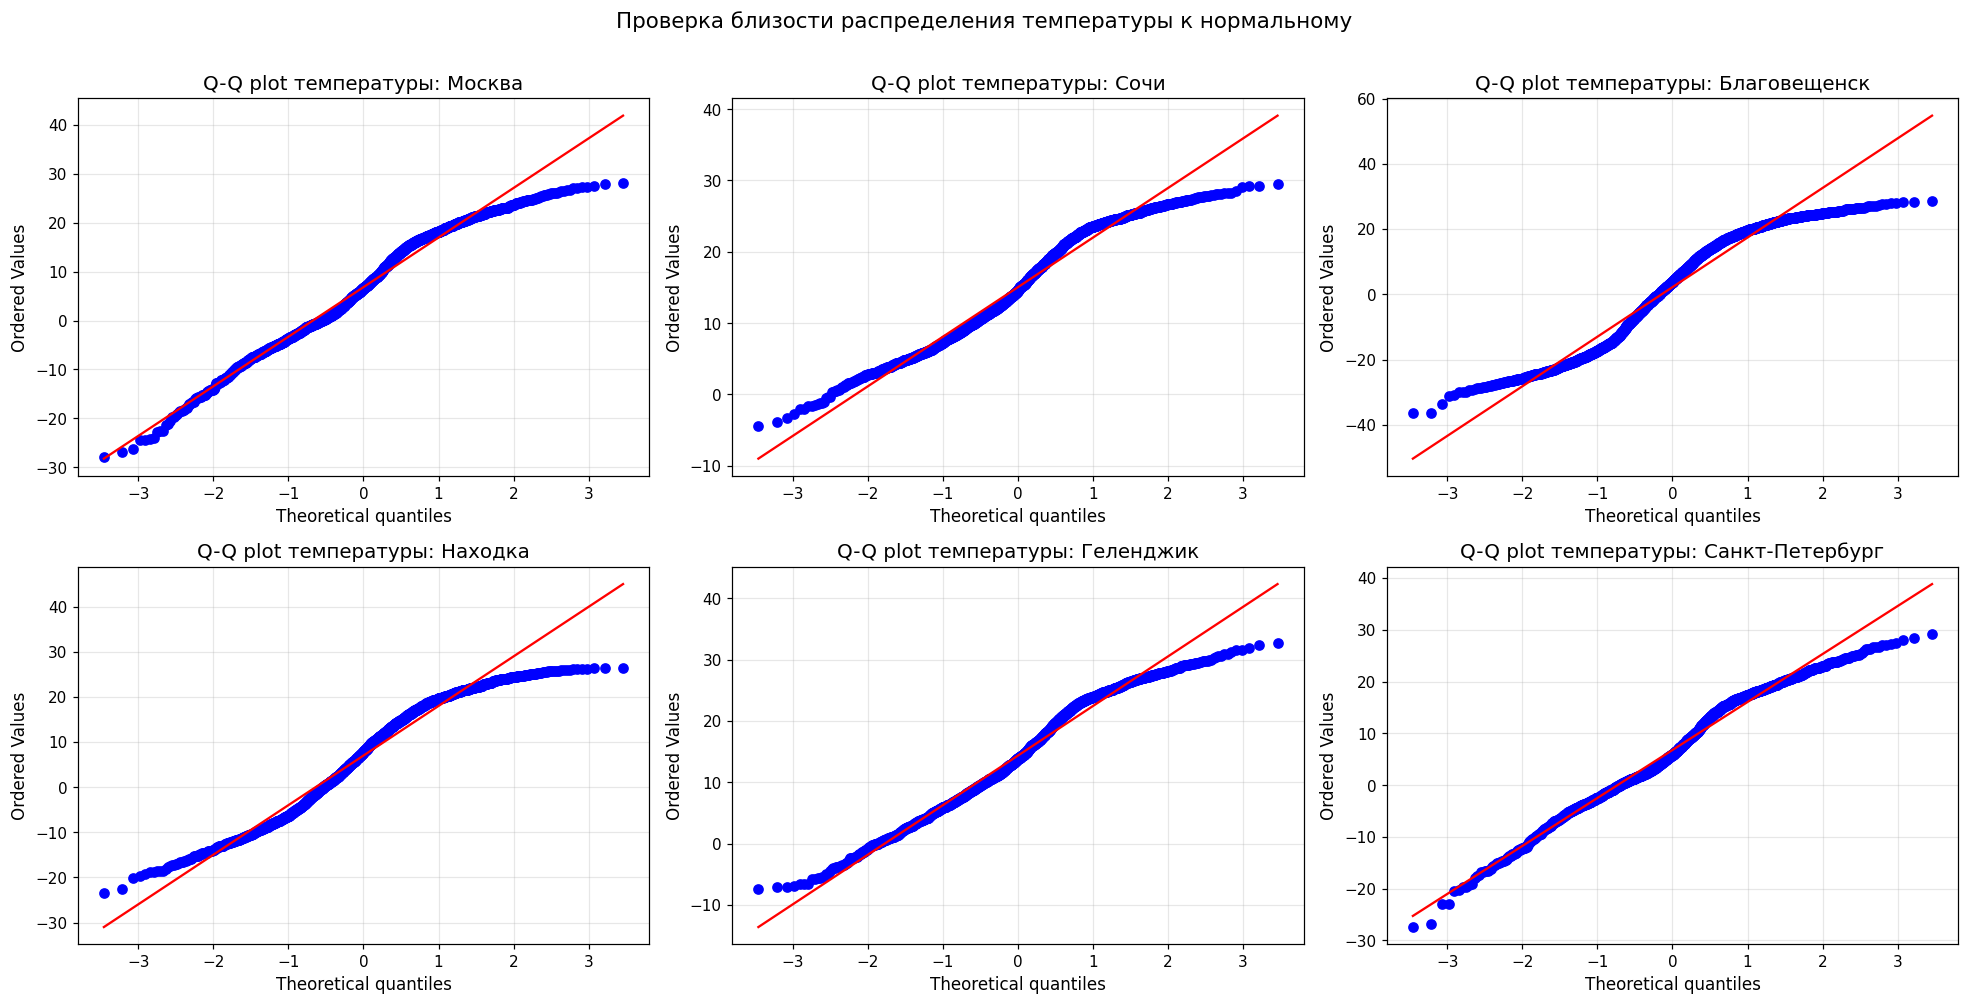

In [10]:
n = len(city_daily)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4.5 * rows))
axes = np.array(axes).reshape(-1)

for ax in axes[n:]:
    ax.axis("off")

for ax, (city, df) in zip(axes, city_daily.items()):
    values = df[TARGET].dropna().values
    probplot(values, dist="norm", plot=ax)
    ax.set_title(f"Q-Q plot температуры: {city}")
    ax.grid(alpha=0.3)

plt.suptitle("Проверка близости распределения температуры к нормальному", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 3.4. Корреляционные матрицы

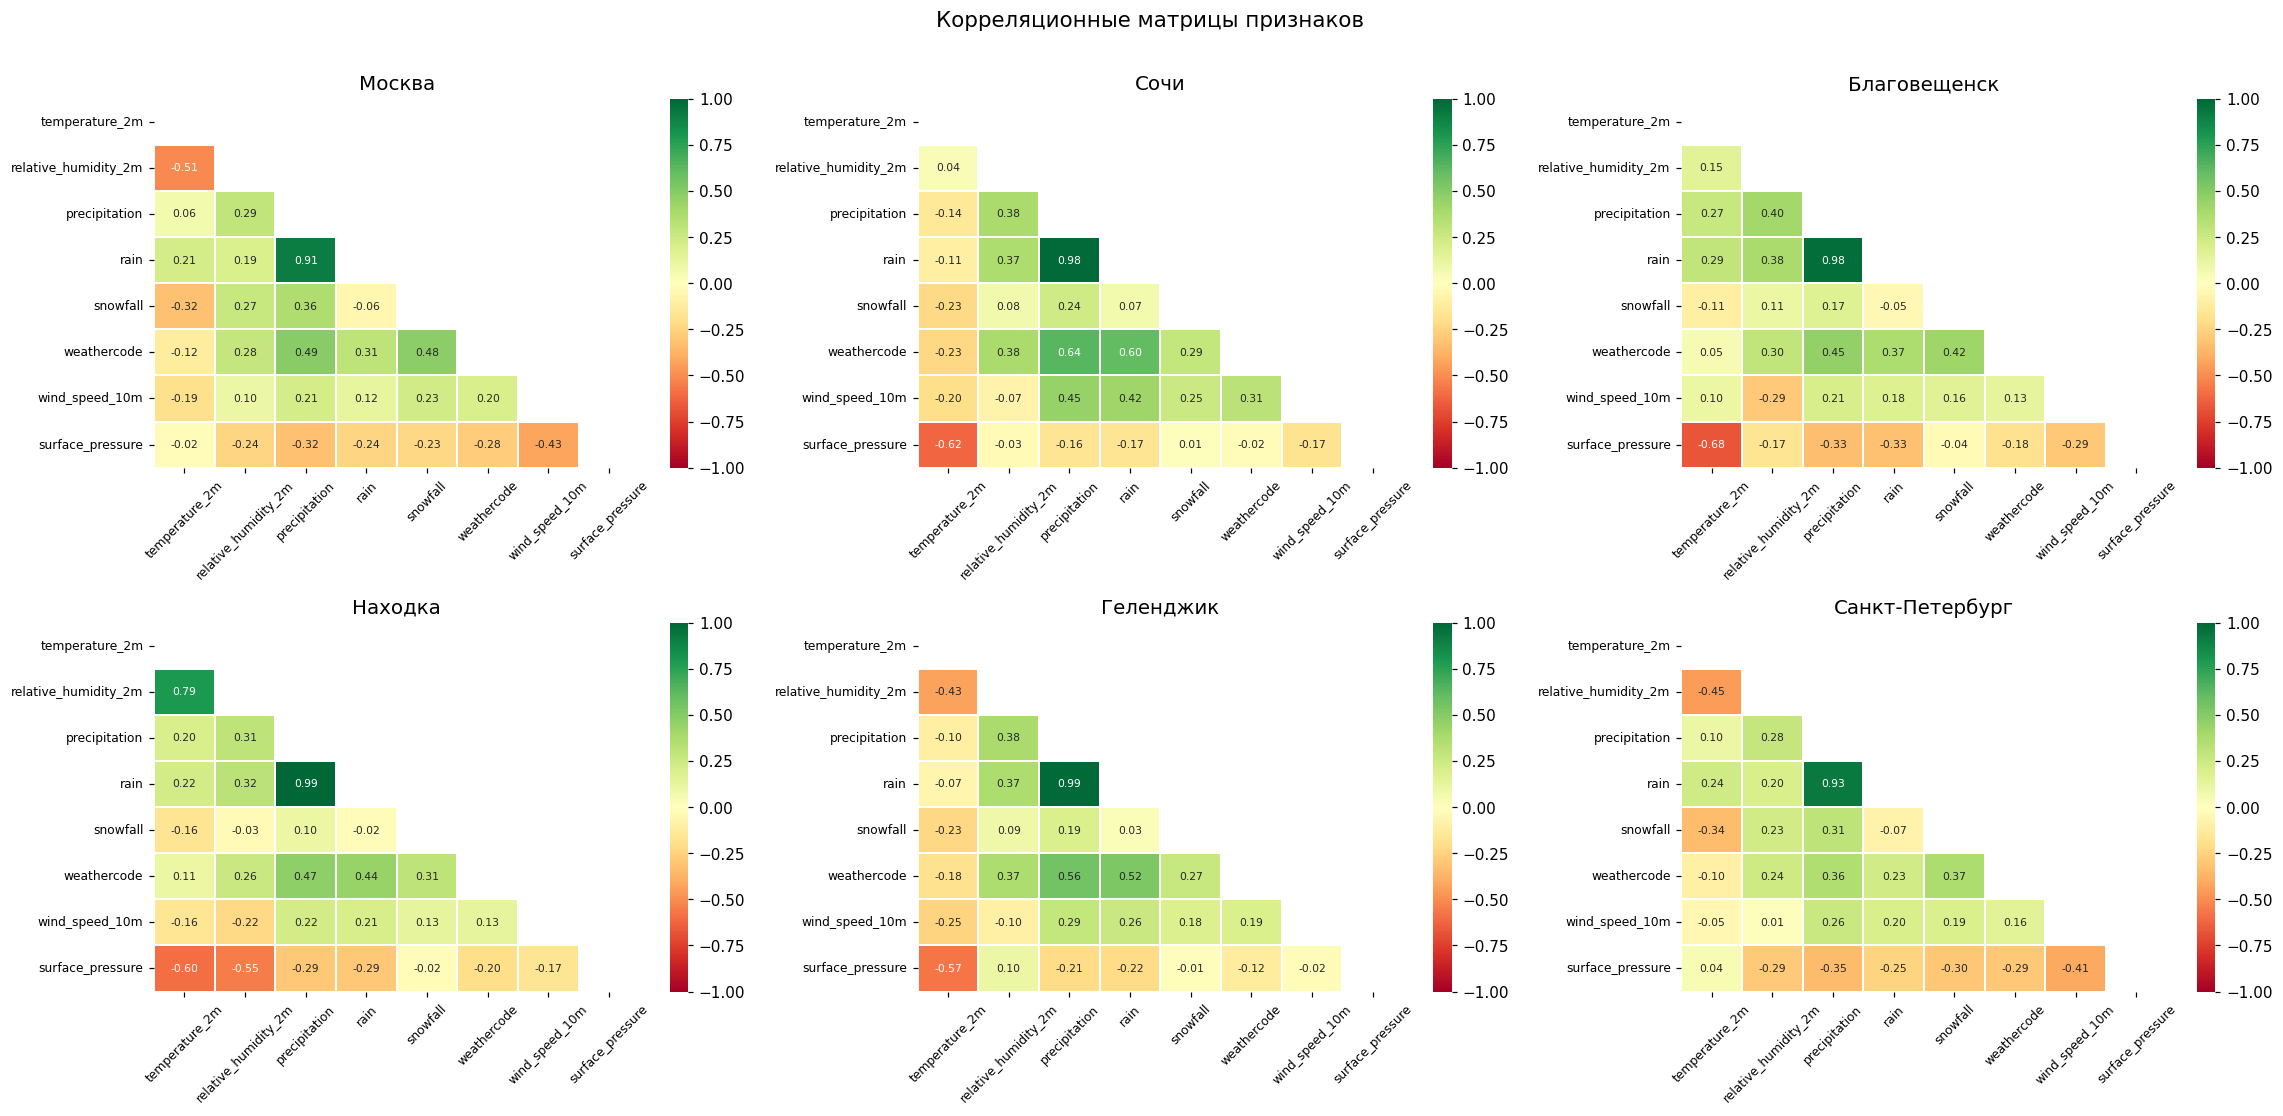

In [11]:
n = len(city_daily)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 5 * rows))
axes = np.array(axes).reshape(-1)

for ax in axes[n:]:
    ax.axis("off")

for ax, (city, df) in zip(axes, city_daily.items()):
    existing_cols = [c for c in FEATURES if c in df.columns]
    corr = df[existing_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    sns.heatmap(
        corr,
        ax=ax,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn",
        center=0,
        vmin=-1,
        vmax=1,
        annot_kws={"size": 7},
        linewidths=0.3,
    )

    ax.set_title(city)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", rotation=0, labelsize=8)

plt.suptitle("Корреляционные матрицы признаков", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 3.5. Сезонная декомпозиция

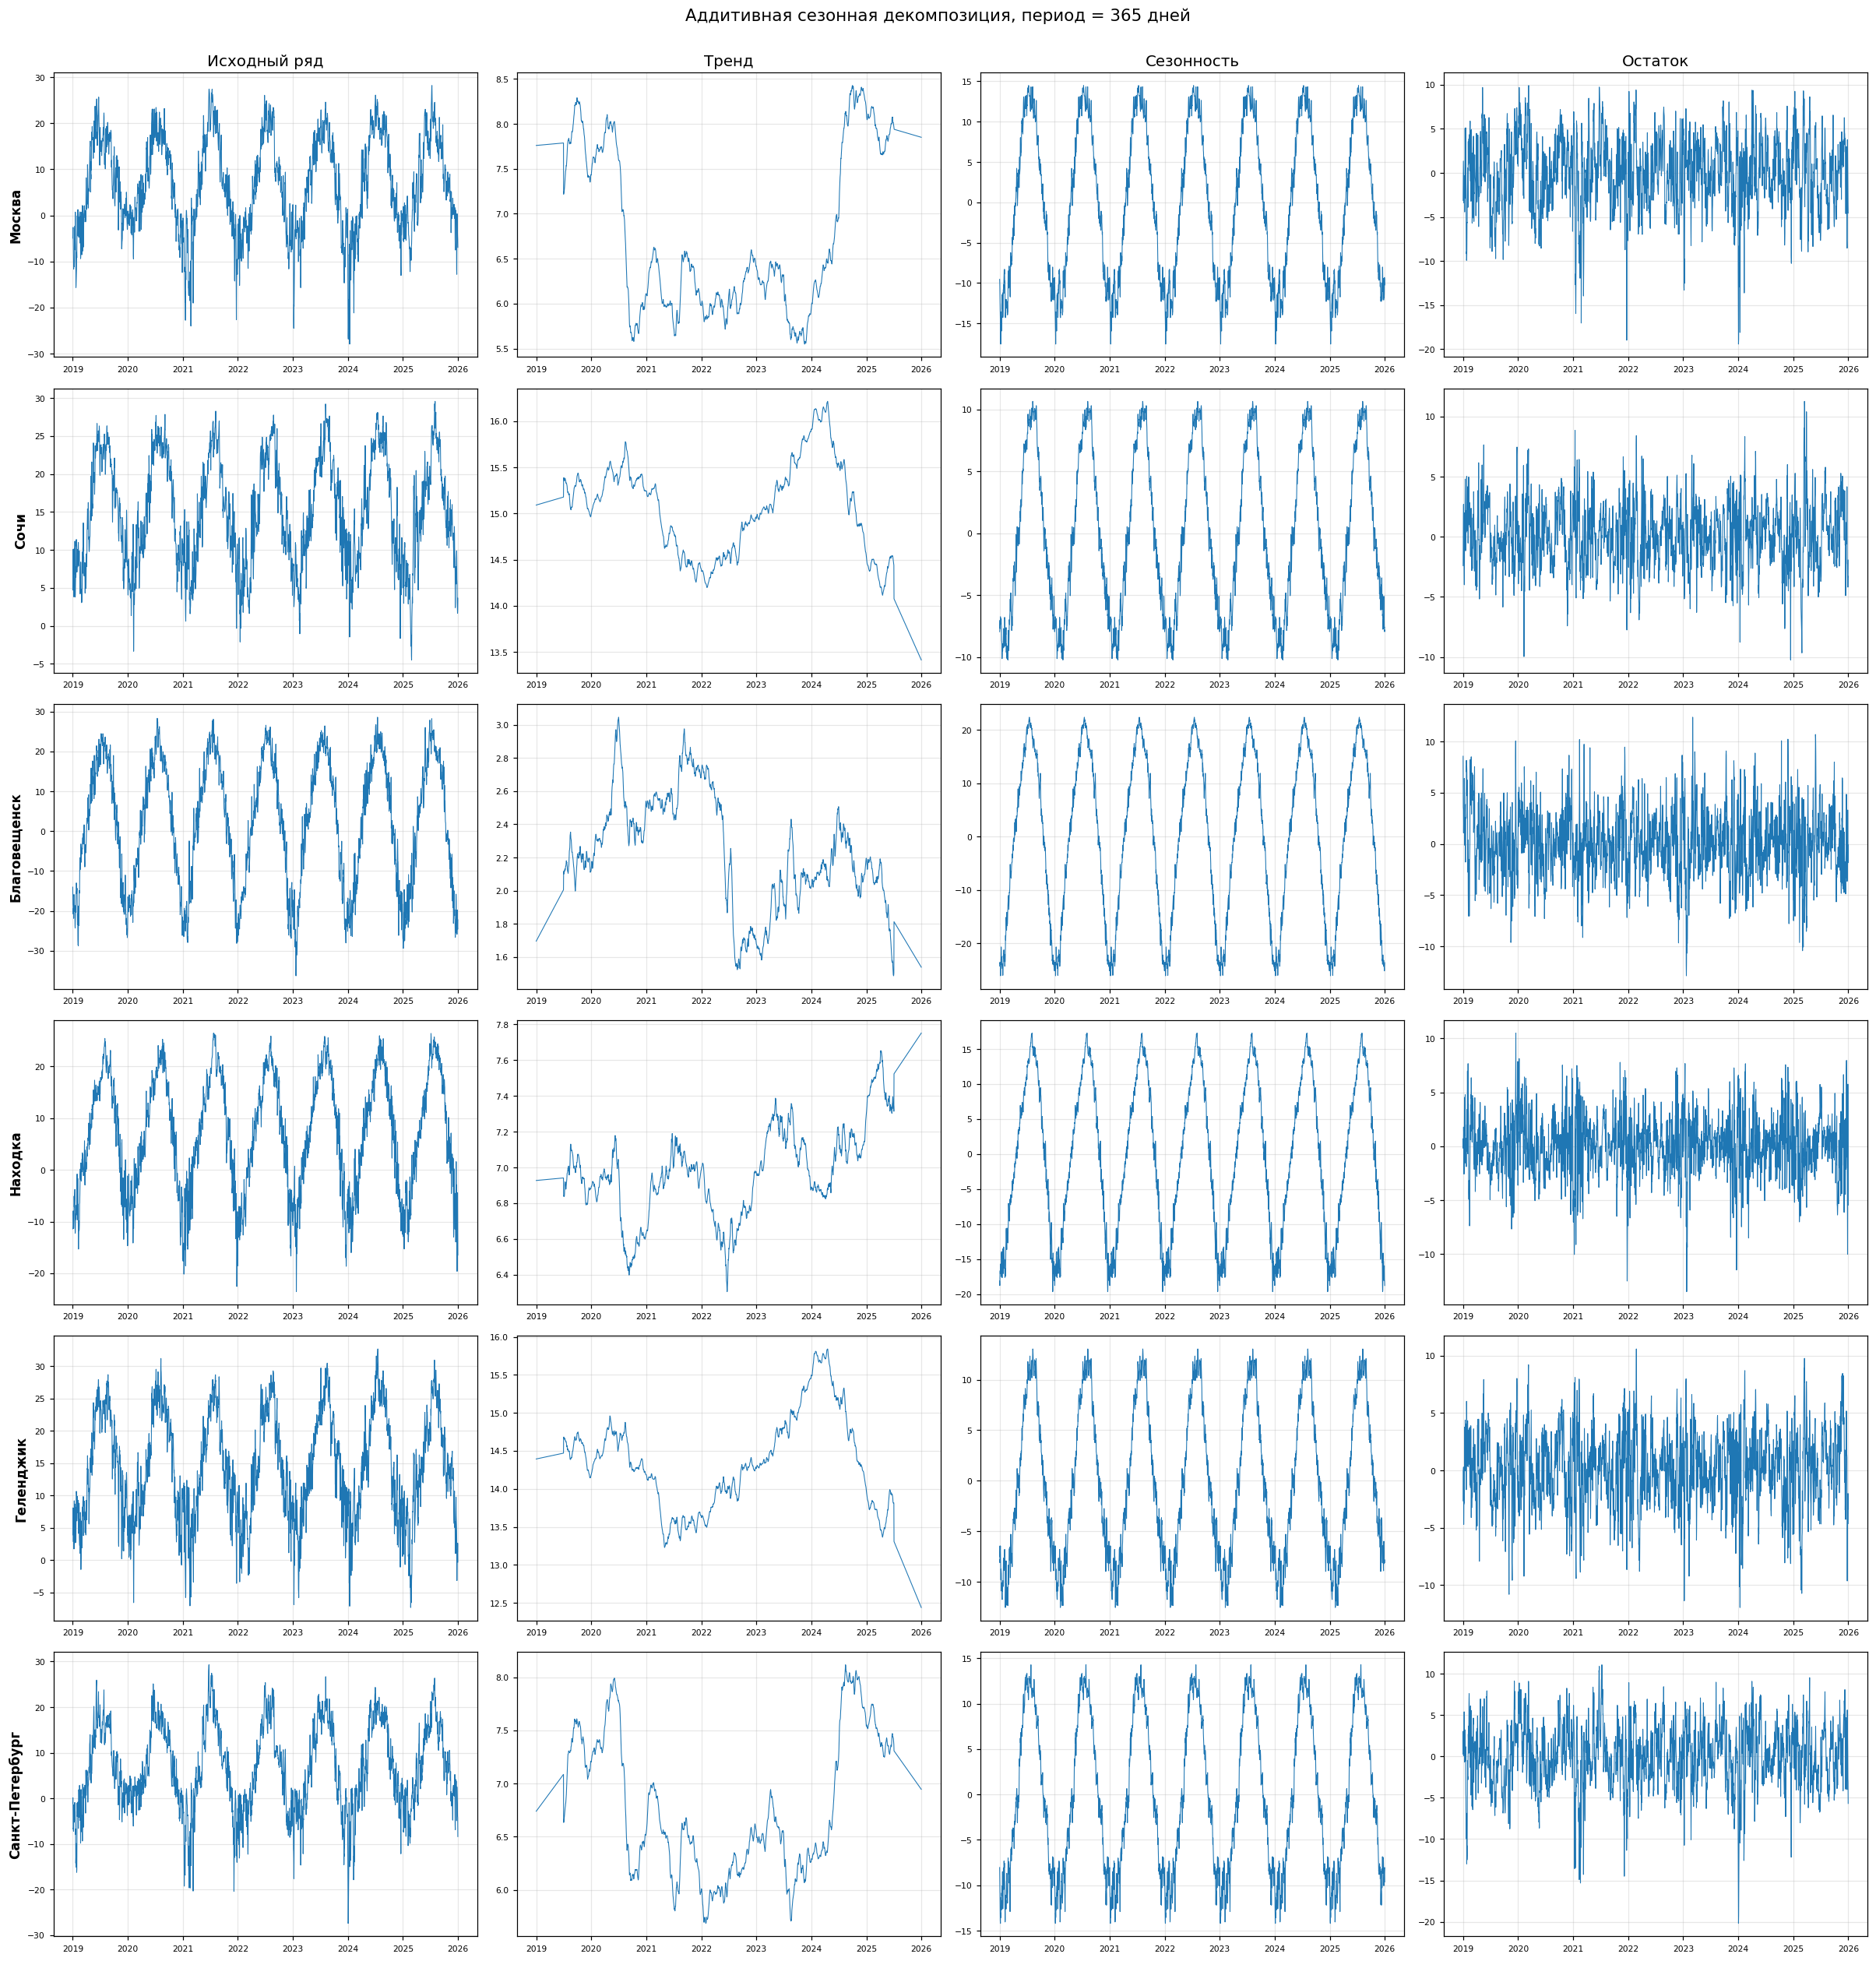

In [12]:
n = len(city_daily)
fig, axes = plt.subplots(n, 4, figsize=(22, 3.8 * n))

if n == 1:
    axes = np.array([axes])

for row, (city, df) in enumerate(city_daily.items()):
    series = df[TARGET].dropna()

    try:
        decomp = seasonal_decompose(series, model="additive", period=365, extrapolate_trend="freq")
        components = [
            (series, "Исходный ряд"),
            (decomp.trend, "Тренд"),
            (decomp.seasonal, "Сезонность"),
            (decomp.resid, "Остаток"),
        ]

        for col, (component, title) in enumerate(components):
            ax = axes[row, col]
            ax.plot(component.index, component.values, linewidth=0.7)
            ax.set_title(title if row == 0 else "")
            ax.grid(alpha=0.3)
            ax.tick_params(labelsize=7)
            if col == 0:
                ax.set_ylabel(city, fontsize=11, fontweight="bold")

    except Exception as exc:
        axes[row, 0].text(0.5, 0.5, f"Ошибка декомпозиции: {exc}", ha="center", va="center")
        for col in range(1, 4):
            axes[row, col].axis("off")

plt.suptitle("Аддитивная сезонная декомпозиция, период = 365 дней", fontsize=14, y=1.002)
plt.tight_layout()
plt.show()

### 3.6. Тест Дики — Фуллера

In [13]:
adf_results = {}

print("=" * 72)
print(f"{'Город':<22} {'ADF-статистика':>15} {'p-value':>12} {'Вывод':>15}")
print("=" * 72)

for city, df in city_daily.items():
    series = df[TARGET].dropna()
    result = adfuller(series, autolag="AIC")

    adf_stat = result[0]
    p_value = result[1]
    stationary = p_value < 0.05

    adf_results[city] = {
        "adf_stat": adf_stat,
        "p_value": p_value,
        "stationary": stationary,
    }

    conclusion = "стационарен" if stationary else "нестационарен"
    print(f"{city:<22} {adf_stat:>15.4f} {p_value:>12.4f} {conclusion:>15}")

print("=" * 72)

Город                   ADF-статистика      p-value           Вывод
Москва                         -3.1582       0.0225     стационарен
Сочи                           -3.0975       0.0267     стационарен
Благовещенск                   -3.3328       0.0135     стационарен
Находка                        -2.8467       0.0519   нестационарен
Геленджик                      -3.0108       0.0339     стационарен
Санкт-Петербург                -3.1835       0.0210     стационарен


**Выводы по EDA:**

- Температурные ряды имеют выраженную годовую сезонность.
- Города демонстрируют разные климатические профили: причерноморские города теплее, Благовещенск имеет более высокую температурную амплитуду, Москва и Санкт-Петербург ближе друг к другу.
- Для моделей машинного обучения стационарность не является обязательным требованием, так как далее используются календарные признаки, лаги и скользящие статистики.

## 4. Инжиниринг признаков

In [14]:
def build_features(df: pd.DataFrame, lags: list[int] | None = None, windows: list[int] | None = None) -> pd.DataFrame:
    if lags is None:
        lags = [1, 2, 3, 7, 14, 30]

    if windows is None:
        windows = [7, 14, 30, 90]

    out = df.copy()

    out["day_of_year"] = out.index.dayofyear
    out["month"] = out.index.month
    out["day_of_week"] = out.index.dayofweek
    out["year"] = out.index.year
    out["season"] = out.index.month % 12 // 3

    out["month_sin"] = np.sin(2 * np.pi * out.index.month / 12)
    out["month_cos"] = np.cos(2 * np.pi * out.index.month / 12)
    out["doy_sin"] = np.sin(2 * np.pi * out.index.dayofyear / 365.25)
    out["doy_cos"] = np.cos(2 * np.pi * out.index.dayofyear / 365.25)

    for lag in lags:
        out[f"temp_lag_{lag}d"] = out[TARGET].shift(lag)

    shifted_temp = out[TARGET].shift(1)

    for window in windows:
        out[f"temp_rollmean_{window}d"] = shifted_temp.rolling(window).mean()
        out[f"temp_rollstd_{window}d"] = shifted_temp.rolling(window).std()
        out[f"temp_rollmin_{window}d"] = shifted_temp.rolling(window).min()
        out[f"temp_rollmax_{window}d"] = shifted_temp.rolling(window).max()

    if "precipitation" in out.columns:
        for window in [7, 30]:
            out[f"precip_rollsum_{window}d"] = out["precipitation"].shift(1).rolling(window).sum()

    if "wind_speed_10m" in out.columns:
        out["wind_rollmax_7d"] = out["wind_speed_10m"].shift(1).rolling(7).max()

    out["temp_diff1"] = out[TARGET].diff(1)
    out["temp_diff2"] = out["temp_diff1"].diff(1)

    if "surface_pressure" in out.columns:
        out["pressure_diff1"] = out["surface_pressure"].diff(1)

    climate_norm = out[TARGET].groupby(out.index.dayofyear).transform("mean")
    out["temp_anomaly"] = out[TARGET] - climate_norm

    return out


city_features = {}

for city, df in city_daily.items():
    city_features[city] = build_features(df)
    city_features[city]["city"] = city
    print(f"{city}: {city_features[city].shape[1]} колонок после построения признаков")

Москва: 47 колонок после построения признаков
Сочи: 47 колонок после построения признаков
Благовещенск: 47 колонок после построения признаков
Находка: 47 колонок после построения признаков
Геленджик: 47 колонок после построения признаков
Санкт-Петербург: 47 колонок после построения признаков


### 4.1. Формирование окон временных рядов для классификации

Классификационный этап строится не как табличная задача по агрегированным признакам, а как задача классификации временных рядов. Один объект классификации — это многомерное окно длиной 90 дней: температура, влажность, осадки, ветер, давление и другие доступные метеопараметры. Метка класса — климатический тип города.

In [15]:
CLASSIFICATION_WINDOW_DAYS = 90
CLASSIFICATION_STEP_DAYS = 30

classification_channels = [col for col in FEATURES if col in next(iter(city_daily.values())).columns]

if TARGET not in classification_channels:
    raise ValueError(f"Целевая температурная колонка {TARGET} отсутствует в данных.")


def extract_ts_windows(
    df: pd.DataFrame,
    climate_label: str,
    city_label: str,
    channels: list[str],
    window_days: int = CLASSIFICATION_WINDOW_DAYS,
    step_days: int = CLASSIFICATION_STEP_DAYS,
) -> tuple[list[np.ndarray], list[str], list[str], list[pd.Timestamp]]:
    X_windows = []
    climate_labels = []
    city_labels = []
    starts = []

    start = df.index.min().normalize()
    end = df.index.max().normalize()
    t = start

    while t + pd.Timedelta(days=window_days - 1) <= end:
        chunk = df.loc[t:t + pd.Timedelta(days=window_days - 1), channels]

        if len(chunk) == window_days and not chunk.isna().any().any():
            X_windows.append(chunk.to_numpy(dtype=float).T)
            climate_labels.append(climate_label)
            city_labels.append(city_label)
            starts.append(t)

        t += pd.Timedelta(days=step_days)

    return X_windows, climate_labels, city_labels, starts


X_parts = []
y_labels = []
window_cities = []
window_starts = []

for city, df in city_daily.items():
    X_city, y_city, cities_city, starts_city = extract_ts_windows(
        df=df,
        climate_label=CLIMATE_GROUPS[city],
        city_label=city,
        channels=classification_channels,
        window_days=CLASSIFICATION_WINDOW_DAYS,
        step_days=CLASSIFICATION_STEP_DAYS,
    )
    X_parts.extend(X_city)
    y_labels.extend(y_city)
    window_cities.extend(cities_city)
    window_starts.extend(starts_city)
    print(f"{city}: окон классификации = {len(X_city)}, тип климата = {CLIMATE_GROUPS[city]}")

X_ts = np.stack(X_parts, axis=0)
y_clf = np.array(y_labels)
window_cities = np.array(window_cities)
window_starts = pd.DatetimeIndex(window_starts)

target_channel_idx = classification_channels.index(TARGET)

print()
print(f"Форма X_ts: {X_ts.shape} = samples × channels × timepoints")
print(f"Каналы: {classification_channels}")
print(f"Классы климатов: {dict(pd.Series(y_clf).value_counts())}")
print(f"Города в окнах: {dict(pd.Series(window_cities).value_counts())}")

Москва: окон классификации = 83, тип климата = умеренно-континентальный
Сочи: окон классификации = 83, тип климата = черноморский
Благовещенск: окон классификации = 83, тип климата = дальневосточный
Находка: окон классификации = 83, тип климата = дальневосточный
Геленджик: окон классификации = 83, тип климата = черноморский
Санкт-Петербург: окон классификации = 83, тип климата = умеренно-континентальный

Форма X_ts: (498, 8, 90) = samples × channels × timepoints
Каналы: ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure']
Классы климатов: {'умеренно-континентальный': 166, 'черноморский': 166, 'дальневосточный': 166}
Города в окнах: {'Москва': 83, 'Сочи': 83, 'Благовещенск': 83, 'Находка': 83, 'Геленджик': 83, 'Санкт-Петербург': 83}


### 4.2. Диагностическая визуализация профилей временных рядов

Перед обучением специализированных классификаторов полезно проверить, что 90-дневные окна действительно содержат различимый климатический сигнал.

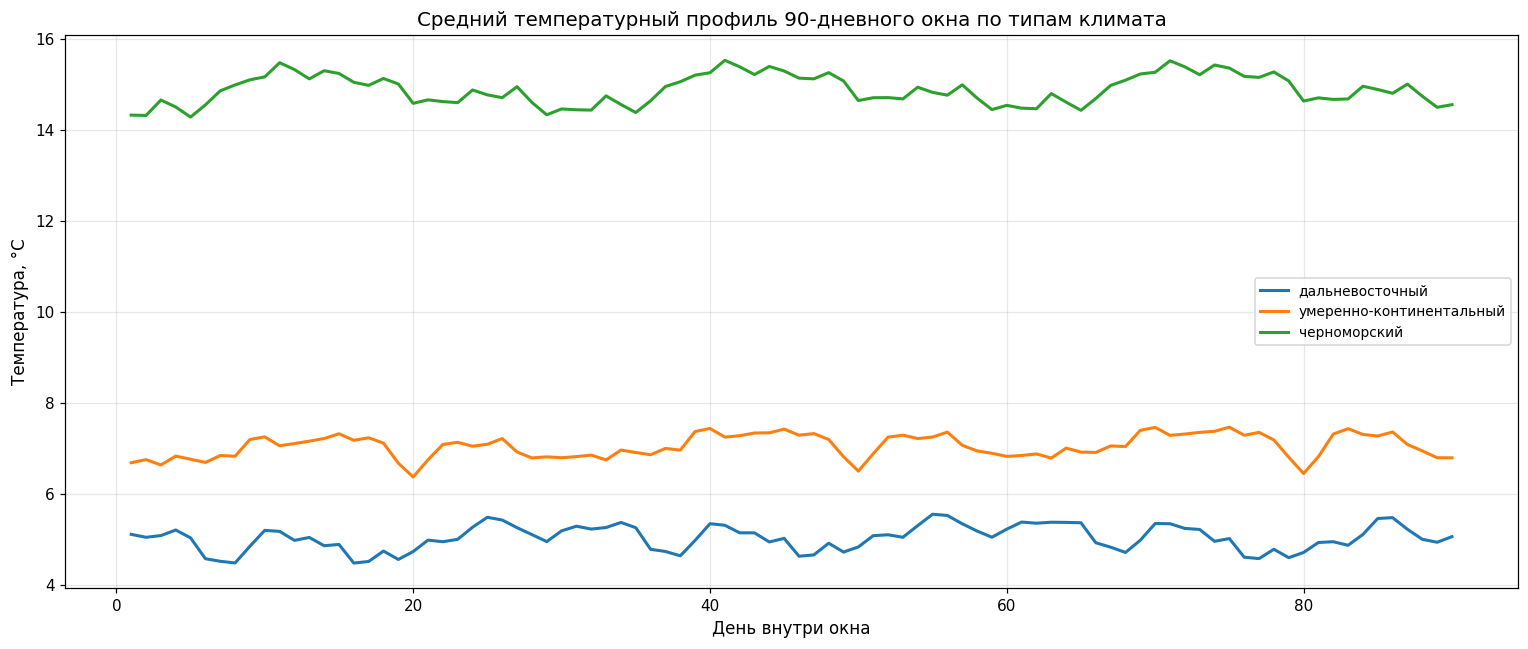

In [16]:
fig, ax = plt.subplots(figsize=(14, 6))

for climate_type in sorted(np.unique(y_clf)):
    mask = y_clf == climate_type
    if not mask.any():
        continue

    mean_profile = X_ts[mask, target_channel_idx, :].mean(axis=0)
    ax.plot(np.arange(1, CLASSIFICATION_WINDOW_DAYS + 1), mean_profile, linewidth=2, label=climate_type)

ax.set_title("Средний температурный профиль 90-дневного окна по типам климата")
ax.set_xlabel("День внутри окна")
ax.set_ylabel("Температура, °C")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.3. PCA-визуализация разделимости климатических групп

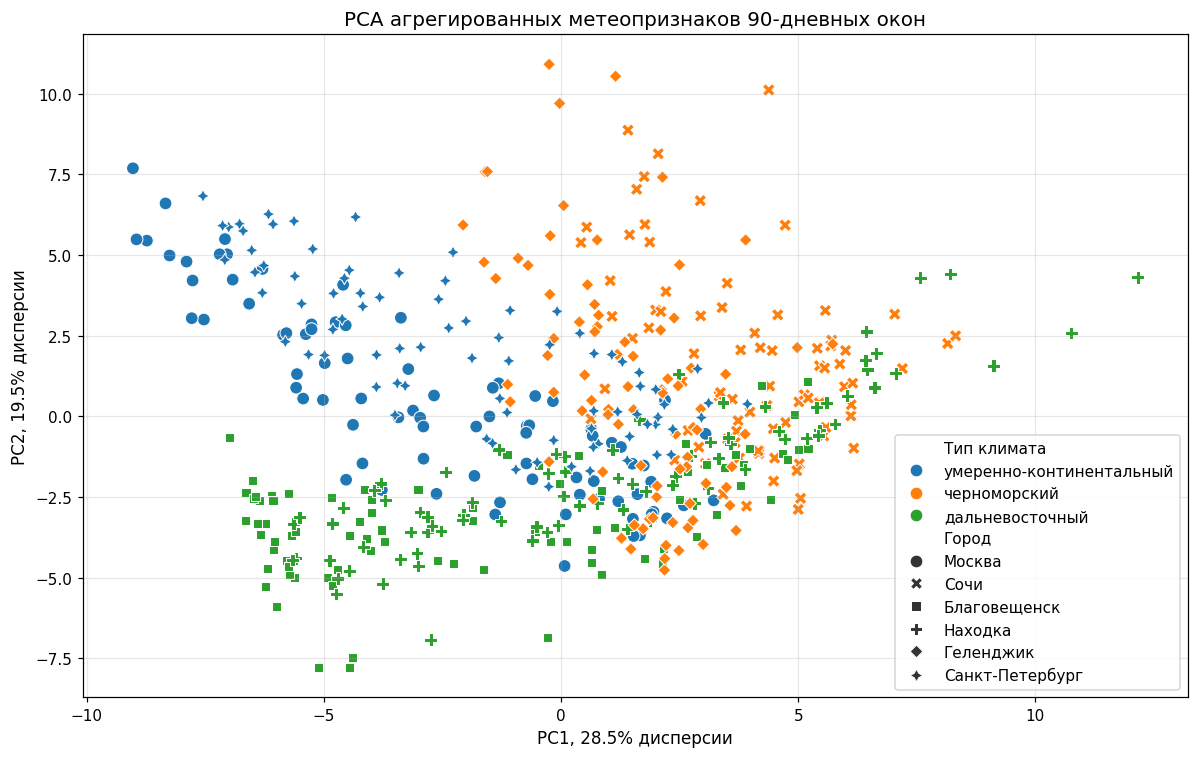

Доля объяснённой дисперсии: [0.285 0.195]
Пояснение: первые две компоненты PCA не обязаны объяснять большую часть дисперсии, поскольку признаки включают разные метеопараметры, лаги и статистики. Здесь PCA используется как визуальная проверка разделимости, а не как основная модель.


In [17]:
def aggregate_window_features(X: np.ndarray, channels: list[str]) -> pd.DataFrame:
    rows = []

    for sample_idx in range(X.shape[0]):
        row = {}
        for channel_idx, channel in enumerate(channels):
            values = X[sample_idx, channel_idx, :]
            row[f"{channel}_mean"] = np.mean(values)
            row[f"{channel}_std"] = np.std(values)
            row[f"{channel}_min"] = np.min(values)
            row[f"{channel}_max"] = np.max(values)
            row[f"{channel}_amplitude"] = np.max(values) - np.min(values)
            row[f"{channel}_q25"] = np.quantile(values, 0.25)
            row[f"{channel}_q75"] = np.quantile(values, 0.75)

        temp_values = X[sample_idx, target_channel_idx, :]
        row["temp_positive_days"] = np.sum(temp_values > 0)
        row["temp_freezing_days"] = np.sum(temp_values < 0)
        rows.append(row)

    return pd.DataFrame(rows)


window_feature_df = aggregate_window_features(X_ts, classification_channels)
window_feature_df["climate_type"] = y_clf
window_feature_df["city"] = window_cities
window_feature_df["window_start"] = window_starts
window_feature_df["season"] = window_starts.month % 12 // 3
window_feature_df["year"] = window_starts.year
window_feature_df["month"] = window_starts.month

metadata_columns = ["climate_type", "city", "window_start", "season", "year", "month"]
feature_cols_for_pca = [col for col in window_feature_df.columns if col not in metadata_columns]
feature_cols_for_pca = [col for col in feature_cols_for_pca if pd.api.types.is_numeric_dtype(window_feature_df[col])]

scaled_window_features = StandardScaler().fit_transform(window_feature_df[feature_cols_for_pca])
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_points = pca.fit_transform(scaled_window_features)

pca_plot_df = pd.DataFrame({
    "PC1": pca_points[:, 0],
    "PC2": pca_points[:, 1],
    "Тип климата": y_clf,
    "Город": window_cities,
})

fig, ax = plt.subplots(figsize=(11, 7))
sns.scatterplot(data=pca_plot_df, x="PC1", y="PC2", hue="Тип климата", style="Город", s=70, ax=ax)
ax.set_title("PCA агрегированных метеопризнаков 90-дневных окон")
ax.set_xlabel(f"PC1, {pca.explained_variance_ratio_[0] * 100:.1f}% дисперсии")
ax.set_ylabel(f"PC2, {pca.explained_variance_ratio_[1] * 100:.1f}% дисперсии")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Доля объяснённой дисперсии:", np.round(pca.explained_variance_ratio_, 3))
print(
    "Пояснение: первые две компоненты PCA не обязаны объяснять большую часть дисперсии, "
    "поскольку признаки включают разные метеопараметры, лаги и статистики. "
    "Здесь PCA используется как визуальная проверка разделимости, а не как основная модель."
)


**Выводы по подготовке классификационных данных:**

- Для классификации используются сами временные ряды фиксированной длины, а не только агрегированные статистики.
- Формат объекта: `samples × channels × timepoints`, где `timepoints = 90` дней.
- Такой формат позволяет применять специализированные модели классификации временных рядов: интервальные леса, DTW-kNN и ROCKET-преобразования.

## 5. Классификация типа климата специализированными моделями временных рядов

**Выбранный подход:** специализированные классификаторы временных рядов из библиотеки `sktime`.

Используются три класса моделей:

1. **ROCKET** — случайные сверточные ядра для извлечения признаков формы временного ряда.
2. **Time Series Forest** — интервальный лес, строящий признаки по случайным временным интервалам.
3. **DTW-kNN** — классификация по расстоянию динамического выравнивания временных рядов.

Основной классификационный этап реализован специализированными моделями временных рядов. Табличная модель используется далее только для вспомогательной интерпретации важности агрегированных признаков.

In [18]:
try:
    from sktime.classification.kernel_based import RocketClassifier
    from sktime.classification.interval_based import TimeSeriesForestClassifier
    from sktime.classification.distance_based import KNeighborsTimeSeriesClassifier
except Exception as exc:
    raise ImportError(
        "Для классификации временных рядов требуется sktime. "
        "Установите его командой: python3 -m pip install sktime"
    ) from exc


def to_nested_dataframe(X: np.ndarray, channel_names: list[str]) -> pd.DataFrame:
    data = {}
    for channel_idx, channel_name in enumerate(channel_names):
        data[channel_name] = [
            pd.Series(X[sample_idx, channel_idx, :]).reset_index(drop=True)
            for sample_idx in range(X.shape[0])
        ]
    return pd.DataFrame(data)


def select_classifier_input(X: np.ndarray, input_kind: str) -> pd.DataFrame:
    if input_kind == "temperature":
        return to_nested_dataframe(X[:, [target_channel_idx], :], [TARGET])
    if input_kind == "multivariate":
        return to_nested_dataframe(X, classification_channels)
    raise ValueError(f"Неизвестный тип входа классификатора: {input_kind}")


In [19]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_clf)

split_date = pd.Timestamp("2025-01-01")
train_mask = window_starts < split_date
test_mask = window_starts >= split_date

if train_mask.sum() == 0 or test_mask.sum() == 0 or len(np.unique(y_encoded[test_mask])) < 2:
    print("Временное разбиение невозможно или слишком мало тестовых классов. Используется стратифицированное разбиение.")
    indices = np.arange(len(y_encoded))
    train_indices, test_indices = train_test_split(
        indices,
        test_size=0.25,
        random_state=RANDOM_STATE,
        stratify=y_encoded,
    )
else:
    train_indices = np.where(train_mask)[0]
    test_indices = np.where(test_mask)[0]

X_train_ts = X_ts[train_indices]
X_test_ts = X_ts[test_indices]
y_train = y_encoded[train_indices]
y_test = y_encoded[test_indices]

train_window_cities = window_cities[train_indices]
test_window_cities = window_cities[test_indices]
test_window_starts = window_starts[test_indices]

print(f"Train: {X_train_ts.shape[0]}")
print(f"Test:  {X_test_ts.shape[0]}")
print("Train climate classes:", dict(pd.Series(label_encoder.inverse_transform(y_train)).value_counts()))
print("Test climate classes:", dict(pd.Series(label_encoder.inverse_transform(y_test)).value_counts()))
print("Test cities:", dict(pd.Series(test_window_cities).value_counts()))

Train: 444
Test:  54
Train climate classes: {'умеренно-континентальный': 148, 'черноморский': 148, 'дальневосточный': 148}
Test climate classes: {'умеренно-континентальный': 18, 'черноморский': 18, 'дальневосточный': 18}
Test cities: {'Москва': 9, 'Сочи': 9, 'Благовещенск': 9, 'Находка': 9, 'Геленджик': 9, 'Санкт-Петербург': 9}


In [20]:
ts_model_specs = {
    "ROCKET_multivariate": {
        "model": RocketClassifier(num_kernels=1000, random_state=RANDOM_STATE),
        "input_kind": "multivariate",
    },
    "TimeSeriesForest_temperature": {
        "model": TimeSeriesForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
        "input_kind": "temperature",
    },
    "DTW_kNN_temperature": {
        "model": KNeighborsTimeSeriesClassifier(n_neighbors=3, distance="dtw"),
        "input_kind": "temperature",
    },
}

cv_scores = {}
test_scores = {}
fitted_models = {}
input_kinds = {}

min_class_count = int(pd.Series(y_train).value_counts().min())
n_splits = min(3, min_class_count)

for name, spec in ts_model_specs.items():
    print()
    print(name)
    print("-" * len(name))

    model = spec["model"]
    input_kind = spec["input_kind"]
    X_train_model = select_classifier_input(X_train_ts, input_kind)
    X_test_model = select_classifier_input(X_test_ts, input_kind)

    if n_splits >= 2:
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
        scores = cross_val_score(
            model,
            X_train_model,
            y_train,
            cv=cv,
            scoring="f1_macro",
            n_jobs=1,
        )
    else:
        scores = np.array([np.nan])

    model.fit(X_train_model, y_train)
    y_pred_model = model.predict(X_test_model)
    test_f1 = f1_score(y_test, y_pred_model, average="macro", zero_division=0)

    cv_scores[name] = scores
    test_scores[name] = test_f1
    fitted_models[name] = model
    input_kinds[name] = input_kind

    print(f"CV F1-macro: {np.nanmean(scores):.4f} ± {np.nanstd(scores):.4f}")
    print(f"Test F1-macro: {test_f1:.4f}")

best_name = max(test_scores, key=test_scores.get)
best_model = fitted_models[best_name]
best_model_input_kind = input_kinds[best_name]

X_test_best = select_classifier_input(X_test_ts, best_model_input_kind)
y_pred = best_model.predict(X_test_best)

print()
print(f"Лучшая модель классификации временных рядов: {best_name}")
print(f"Тип входа лучшей модели: {best_model_input_kind}")


ROCKET_multivariate
-------------------
CV F1-macro: 0.9932 ± 0.0055
Test F1-macro: 0.8878

TimeSeriesForest_temperature
----------------------------
CV F1-macro: 0.7881 ± 0.0306
Test F1-macro: 0.7221

DTW_kNN_temperature
-------------------
CV F1-macro: 0.7572 ± 0.0118
Test F1-macro: 0.6304

Лучшая модель классификации временных рядов: ROCKET_multivariate
Тип входа лучшей модели: multivariate


## 6. Оценка классификации

In [21]:
y_test_labels = label_encoder.inverse_transform(y_test)
y_pred_labels = label_encoder.inverse_transform(y_pred)

print("Classification Report:")
print(classification_report(y_test_labels, y_pred_labels, zero_division=0))

classification_accuracy = accuracy_score(y_test_labels, y_pred_labels)
print(f"Accuracy: {classification_accuracy:.4f}")


Classification Report:
                          precision    recall  f1-score   support

         дальневосточный       0.95      1.00      0.97        18
умеренно-континентальный       0.83      0.83      0.83        18
            черноморский       0.88      0.83      0.86        18

                accuracy                           0.89        54
               macro avg       0.89      0.89      0.89        54
            weighted avg       0.89      0.89      0.89        54

Accuracy: 0.8889


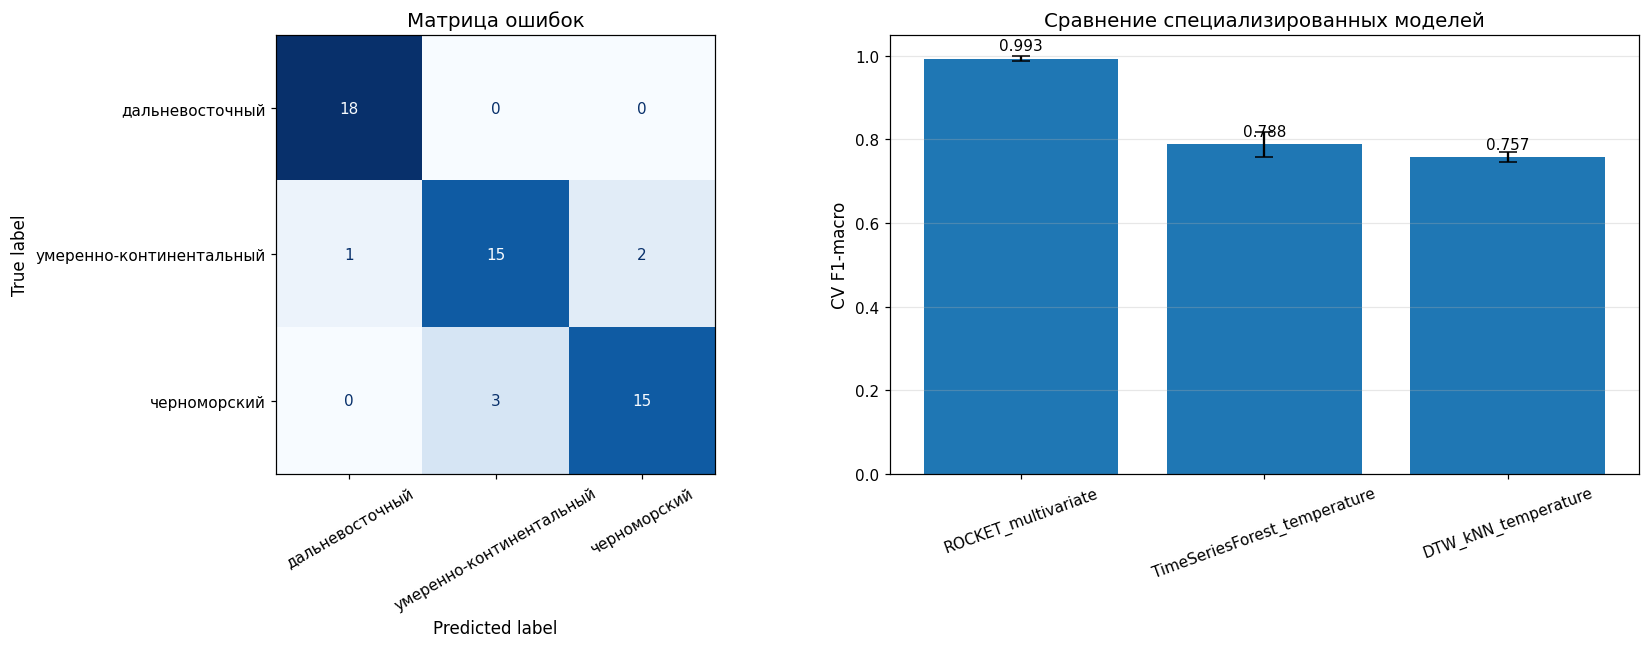

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test_labels, y_pred_labels, labels=label_encoder.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Матрица ошибок")
axes[0].tick_params(axis="x", rotation=30)

names = list(cv_scores.keys())
means = [np.nanmean(cv_scores[name]) for name in names]
stds = [np.nanstd(cv_scores[name]) for name in names]

bars = axes[1].bar(names, means, yerr=stds, capsize=6)
axes[1].set_ylabel("CV F1-macro")
axes[1].set_title("Сравнение специализированных моделей")
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y", alpha=0.3)

for bar, mean in zip(bars, means):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        min(mean + 0.02, 1.02),
        f"{mean:.3f}",
        ha="center",
        fontsize=10,
    )

plt.tight_layout()
plt.show()


ROC-AUC macro, One-vs-Rest: 0.9167


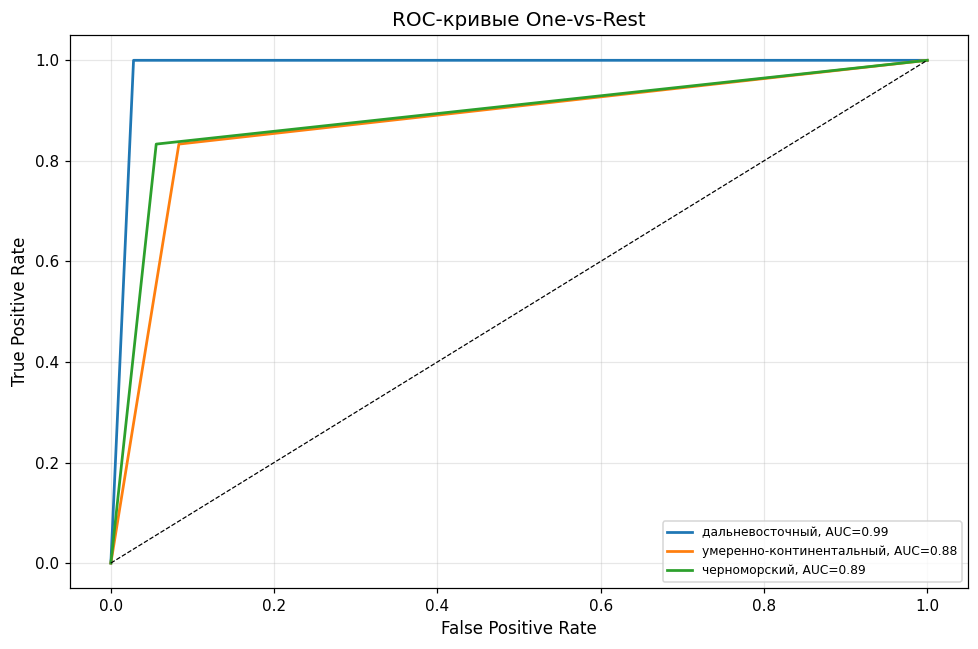

In [23]:
X_test_for_proba = select_classifier_input(X_test_ts, best_model_input_kind)

if hasattr(best_model, "predict_proba"):
    y_prob = best_model.predict_proba(X_test_for_proba)

    try:
        roc_auc_macro = roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro")
        print(f"ROC-AUC macro, One-vs-Rest: {roc_auc_macro:.4f}")

        y_test_bin = label_binarize(y_test, classes=list(range(len(label_encoder.classes_))))
        fig, ax = plt.subplots(figsize=(9, 6))

        for i, climate_type in enumerate(label_encoder.classes_):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
            class_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, linewidth=1.8, label=f"{climate_type}, AUC={class_auc:.2f}")

        ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.set_title("ROC-кривые One-vs-Rest")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    except Exception as exc:
        roc_auc_macro = np.nan
        print(f"ROC-AUC не рассчитан: {exc}")
else:
    y_prob = None
    roc_auc_macro = np.nan
    print("У выбранной модели нет predict_proba, ROC-AUC не рассчитан.")


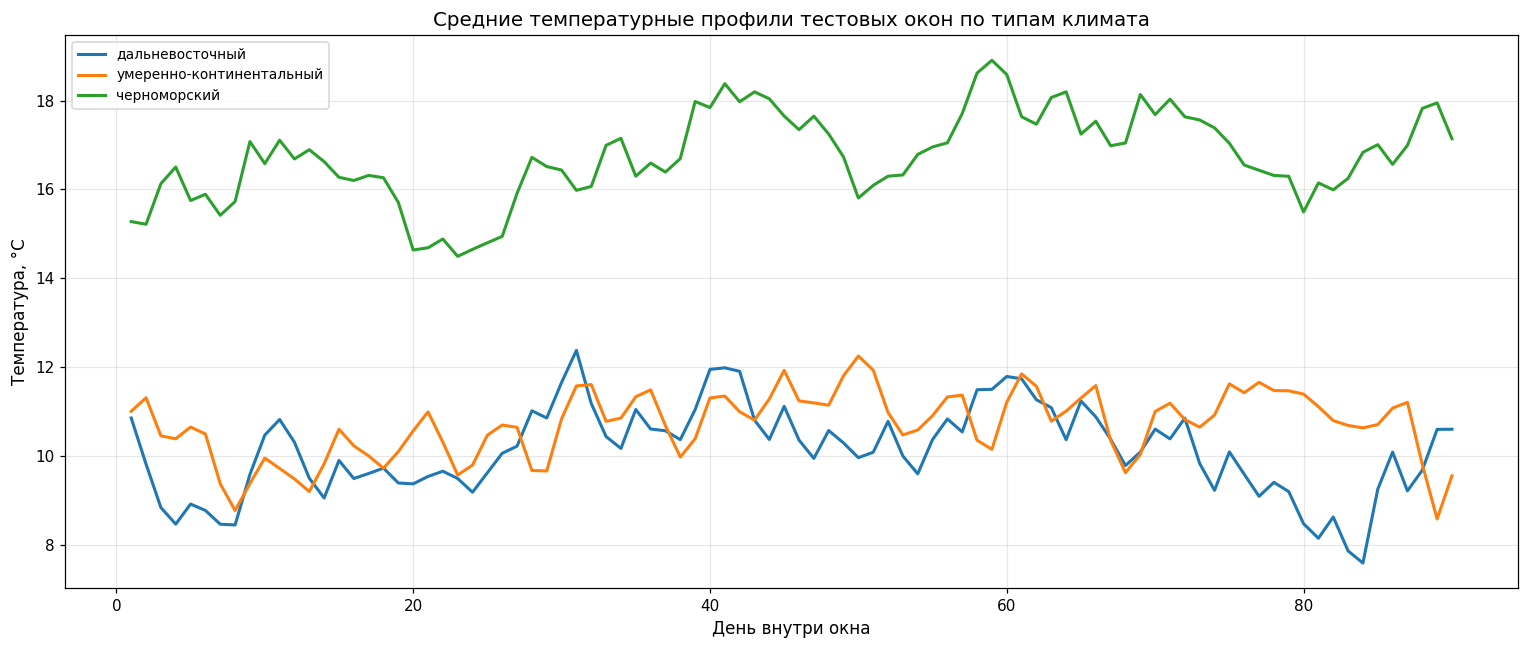

F1-macro интерпретируемой модели: 0.8222
Permutation importance для интерпретируемой модели на агрегированных метеопризнаках:


,feature,importance_mean,importance_std,gini_importance
51,surface_pressure_min,0.0532,0.0253,0.1523
54,surface_pressure_q25,0.0238,0.0144,0.0741
0,temperature_2m_mean,0.0000,0.0000,0.0138
41,weathercode_q75,0.0000,0.0000,0.0008
30,snowfall_min,0.0000,0.0000,0.0000
31,snowfall_max,0.0000,0.0000,0.0024
32,snowfall_amplitude,0.0000,0.0000,0.0018
33,snowfall_q25,0.0000,0.0000,0.0000
34,snowfall_q75,0.0000,0.0000,0.0036
35,weathercode_mean,0.0000,0.0000,0.0126


Групповая важность исходных метеопараметров:


,feature_group,importance_drop_f1_macro,columns_in_group
7,surface_pressure,0.3617,7
6,wind_speed_10m,0.0749,7
0,temperature_2m,0.0333,7
1,relative_humidity_2m,0.0000,7
2,precipitation,0.0000,7
3,rain,0.0000,7
4,snowfall,0.0000,7
5,weathercode,0.0000,7


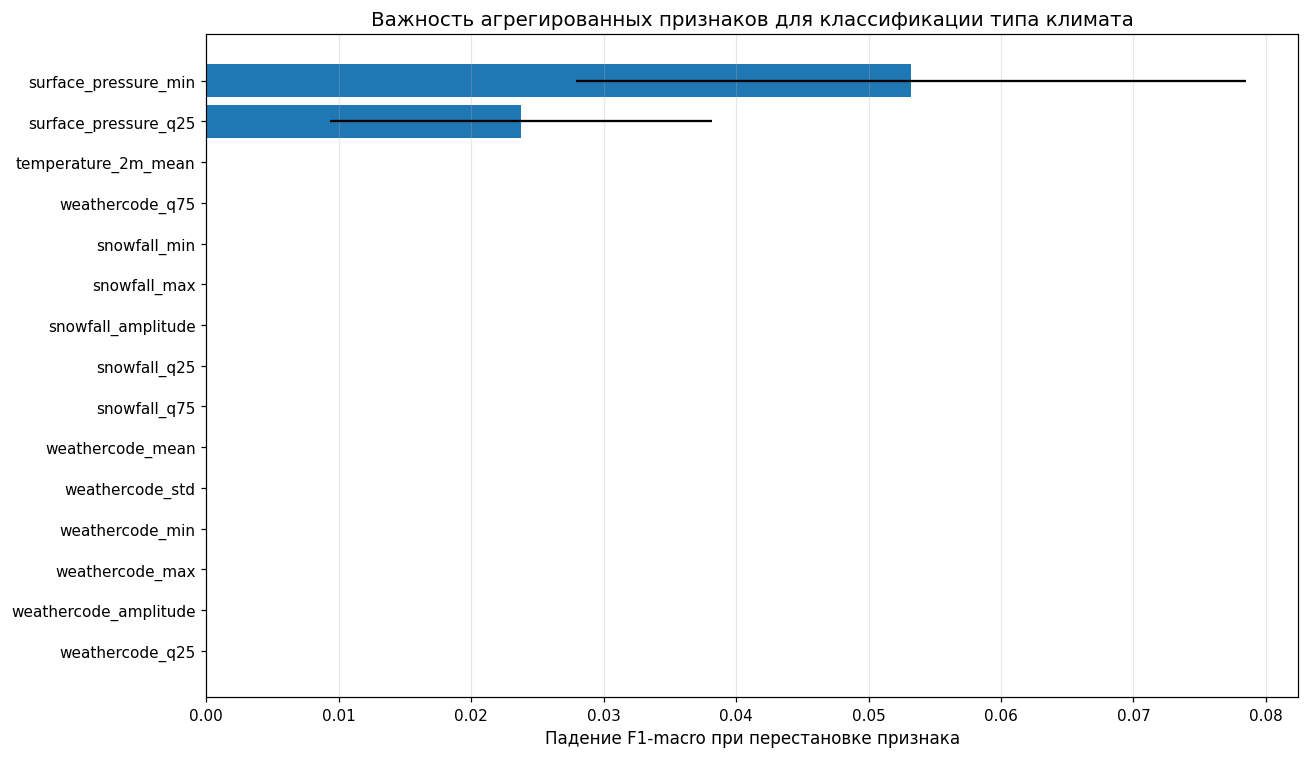

Пояснение: большое число нулевых permutation importance допустимо для случайного леса при сильной корреляции агрегированных признаков. Если один признак переставить, модель может использовать его дубли: mean/q25/q75/min/max одного и того же метеопараметра. Поэтому дополнительно выведена групповая важность по исходным метеопараметрам.


In [24]:
fig, ax = plt.subplots(figsize=(14, 6))

for climate_type in label_encoder.classes_:
    mask = y_test_labels == climate_type
    if not mask.any():
        continue

    mean_true_profile = X_test_ts[mask, target_channel_idx, :].mean(axis=0)
    ax.plot(
        np.arange(1, CLASSIFICATION_WINDOW_DAYS + 1),
        mean_true_profile,
        linewidth=2,
        label=climate_type,
    )

ax.set_title("Средние температурные профили тестовых окон по типам климата")
ax.set_xlabel("День внутри окна")
ax.set_ylabel("Температура, °C")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

train_feature_table = window_feature_df.iloc[train_indices][feature_cols_for_pca].copy()
test_feature_table = window_feature_df.iloc[test_indices][feature_cols_for_pca].copy()

rf_interpreter = RandomForestClassifier(
    n_estimators=700,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    min_samples_leaf=2,
    n_jobs=-1,
)
rf_interpreter.fit(train_feature_table, y_train)

interpreter_pred = rf_interpreter.predict(test_feature_table)
print(f"F1-macro интерпретируемой модели: {f1_score(y_test, interpreter_pred, average='macro'):.4f}")

perm = permutation_importance(
    rf_interpreter,
    test_feature_table,
    y_test,
    scoring="f1_macro",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature": feature_cols_for_pca,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
    "gini_importance": rf_interpreter.feature_importances_,
}).sort_values("importance_mean", ascending=False)

print("Permutation importance для интерпретируемой модели на агрегированных метеопризнаках:")
display(importance_df.head(20).round(4))

family_rows = []
for base_feature in classification_channels:
    family_cols = [col for col in feature_cols_for_pca if col.startswith(base_feature + "_")]
    if not family_cols:
        continue

    X_permuted = test_feature_table.copy()
    rng = np.random.default_rng(RANDOM_STATE)
    shuffled_index = rng.permutation(len(X_permuted))
    X_permuted.loc[:, family_cols] = X_permuted.iloc[shuffled_index][family_cols].to_numpy()

    base_score = f1_score(y_test, interpreter_pred, average="macro")
    perm_score = f1_score(y_test, rf_interpreter.predict(X_permuted), average="macro")
    family_rows.append({
        "feature_group": base_feature,
        "importance_drop_f1_macro": base_score - perm_score,
        "columns_in_group": len(family_cols),
    })

family_importance_df = pd.DataFrame(family_rows).sort_values("importance_drop_f1_macro", ascending=False)
print("Групповая важность исходных метеопараметров:")
display(family_importance_df.round(4))

fig, ax = plt.subplots(figsize=(12, 7))
top_importance = importance_df.head(15).iloc[::-1]
ax.barh(top_importance["feature"], top_importance["importance_mean"], xerr=top_importance["importance_std"])
ax.set_title("Важность агрегированных признаков для классификации типа климата")
ax.set_xlabel("Падение F1-macro при перестановке признака")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

if (importance_df["importance_mean"].abs() < 1e-12).mean() > 0.5:
    print(
        "Пояснение: большое число нулевых permutation importance допустимо для случайного леса "
        "при сильной корреляции агрегированных признаков. Если один признак переставить, модель может "
        "использовать его дубли: mean/q25/q75/min/max одного и того же метеопараметра. Поэтому дополнительно "
        "выведена групповая важность по исходным метеопараметрам."
    )


Матрица ошибок в табличном виде:


pred,дальневосточный,умеренно-континентальный,черноморский
true,,,
дальневосточный,18,0,0
умеренно-континентальный,1,15,2
черноморский,0,3,15



Наиболее частые ошибки:
черноморский → умеренно-континентальный: 3
умеренно-континентальный → черноморский: 2
умеренно-континентальный → дальневосточный: 1

Качество классификации по сезонам:


,accuracy,windows
season,,
весна,0.9440,18
зима,0.6670,12
лето,0.9440,18
осень,1.0000,6


Качество классификации по месяцам:


,accuracy,windows
month,,
1,0.8330,6
2,0.5000,6
3,1.0000,6
4,0.8330,6
5,1.0000,6
6,1.0000,6
7,1.0000,6
8,0.8330,6
9,1.0000,6


Качество классификации по годам:


,accuracy,windows
year,,
2025,0.8890,54


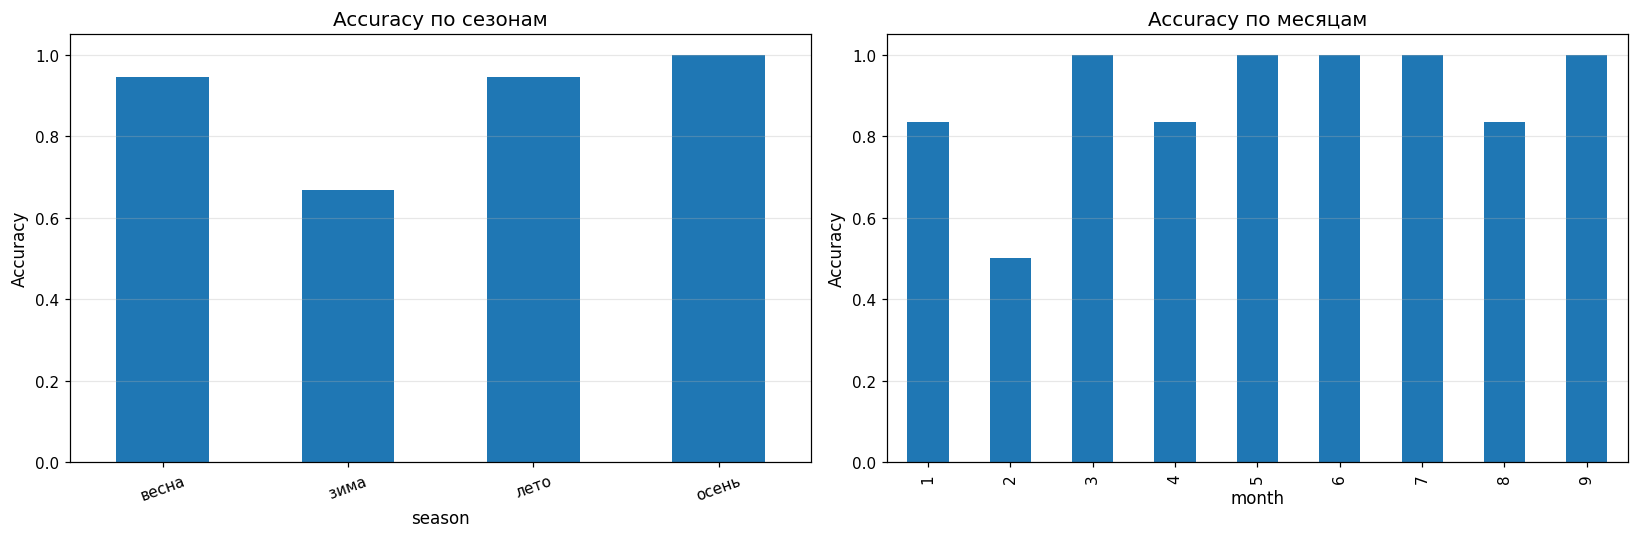

In [25]:
error_df = pd.DataFrame({
    "true": y_test_labels,
    "pred": y_pred_labels,
    "city": test_window_cities,
    "window_start": test_window_starts,
    "month": test_window_starts.month,
    "year": test_window_starts.year,
    "season_id": test_window_starts.month % 12 // 3,
})
error_df["season"] = error_df["season_id"].map({0: "зима", 1: "весна", 2: "лето", 3: "осень"})
error_df["correct"] = error_df["true"] == error_df["pred"]

error_matrix = pd.crosstab(error_df["true"], error_df["pred"])

print("Матрица ошибок в табличном виде:")
display(error_matrix)

off_diag = error_matrix.copy()

for i in range(min(off_diag.shape)):
    off_diag.iloc[i, i] = 0

pairs = []

for true_class in off_diag.index:
    for pred_class in off_diag.columns:
        count = int(off_diag.loc[true_class, pred_class])
        if count > 0:
            pairs.append((true_class, pred_class, count))

pairs = sorted(pairs, key=lambda x: -x[2])

print()
print("Наиболее частые ошибки:")
if pairs:
    for true_class, pred_class, count in pairs[:5]:
        print(f"{true_class} → {pred_class}: {count}")
else:
    print("Ошибок на тестовой выборке нет.")

season_quality = error_df.groupby("season")["correct"].agg(["mean", "count"]).rename(columns={"mean": "accuracy", "count": "windows"})
month_quality = error_df.groupby("month")["correct"].agg(["mean", "count"]).rename(columns={"mean": "accuracy", "count": "windows"})
year_quality = error_df.groupby("year")["correct"].agg(["mean", "count"]).rename(columns={"mean": "accuracy", "count": "windows"})

print("\nКачество классификации по сезонам:")
display(season_quality.round(3))

print("Качество классификации по месяцам:")
display(month_quality.round(3))

print("Качество классификации по годам:")
display(year_quality.round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
season_quality["accuracy"].plot(kind="bar", ax=axes[0])
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Accuracy по сезонам")
axes[0].set_ylabel("Accuracy")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.3)

month_quality["accuracy"].plot(kind="bar", ax=axes[1])
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Accuracy по месяцам")
axes[1].set_ylabel("Accuracy")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Выводы по классификации:**

- Классификация выполнена специализированными моделями временных рядов, а не обычными табличными бустингами.
- ROCKET использует форму многомерного временного ряда через случайные сверточные преобразования.
- Time Series Forest анализирует интервалы внутри ряда, что соответствует идее поиска информативных временных фрагментов.
- DTW-kNN сравнивает форму температурных рядов с учётом возможных локальных сдвигов.
- Ошибки ожидаемо возникают между климатически близкими городами: Москва / Санкт-Петербург и Сочи / Геленджик.

## 7. Прогнозирование температуры на горизонте 30 дней

Для каждого города обучается отдельная модель прогнозирования. Основной вариант — LightGBM; если LightGBM недоступен в окружении macOS, используется HistGradientBoostingRegressor из scikit-learn.

**Целевые переменные:** температуры через 1, 2, 3,..., 30 дней относительно текущей даты наблюдения.

**Разбиение по времени:**

- обучение: 2019–2023;
- валидация: 2024;
- тест: 2025.

Такое разбиение исключает перемешивание будущих наблюдений с прошлыми и лучше соответствует реальному сценарию прогноза.

In [26]:
HORIZON = 30
FORECAST_HORIZONS = list(range(1, HORIZON + 1))


def build_forecast_dataset(
    df: pd.DataFrame,
    horizons: list[int] | None = None,
    lags: list[int] | None = None,
    windows: list[int] | None = None,
):
    if horizons is None:
        horizons = FORECAST_HORIZONS

    if lags is None:
        lags = [1, 2, 3, 7, 14, 30, 60, 90]

    if windows is None:
        windows = [7, 14, 30, 90]

    features = build_features(df, lags=lags, windows=windows)

    target_columns = []
    for horizon in horizons:
        col = f"target_h{horizon}"
        features[col] = features[TARGET].shift(-horizon)
        target_columns.append(col)

    features = features.dropna()

    forecast_feature_columns = [
        col for col in features.columns
        if col not in [TARGET, "city"] + target_columns
    ]

    X = features[forecast_feature_columns]
    y = features[target_columns]
    idx = features.index

    return X, y, idx, forecast_feature_columns, target_columns


def split_by_year(
    X: pd.DataFrame,
    y: pd.DataFrame,
    idx: pd.DatetimeIndex,
    train_end: str = "2023-12-31",
    val_end: str = "2024-12-31",
):
    train_end = pd.Timestamp(train_end)
    val_end = pd.Timestamp(val_end)

    mask_train = idx <= train_end
    mask_val = (idx > train_end) & (idx <= val_end)
    mask_test = idx > val_end

    return (
        X.loc[mask_train],
        y.loc[mask_train],
        X.loc[mask_val],
        y.loc[mask_val],
        X.loc[mask_test],
        y.loc[mask_test],
        idx[mask_test],
    )


def mean_absolute_percentage_error_safe(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    denom = np.maximum(np.abs(y_true), 1e-6)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

In [27]:
forecast_models = {}
forecast_results = {}
forecast_feature_columns_by_city = {}
forecast_model_name = "LightGBM" if LIGHTGBM_AVAILABLE else "HistGradientBoostingRegressor"

for city, df in city_daily.items():
    print()
    print(city)
    print("-" * len(city))

    X, y, idx, forecast_feature_columns, target_columns = build_forecast_dataset(df, horizons=FORECAST_HORIZONS)
    X_train_f, y_train_f, X_val_f, y_val_f, X_test_f, y_test_f, idx_test_f = split_by_year(X, y, idx)

    print(f"Train: {len(X_train_f)}, Val: {len(X_val_f)}, Test: {len(X_test_f)}")

    if len(X_train_f) == 0 or len(X_val_f) == 0 or len(X_test_f) == 0:
        print("Недостаточно данных, город пропущен.")
        continue

    if LIGHTGBM_AVAILABLE:
        base_model = lgb.LGBMRegressor(
            n_estimators=250,
            learning_rate=0.04,
            num_leaves=63,
            min_child_samples=20,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )
    else:
        base_model = HistGradientBoostingRegressor(
            max_iter=350,
            learning_rate=0.04,
            max_leaf_nodes=63,
            random_state=RANDOM_STATE,
        )

    model = MultiOutputRegressor(base_model, n_jobs=1)
    model.fit(pd.concat([X_train_f, X_val_f]), pd.concat([y_train_f, y_val_f]))

    y_pred_matrix = model.predict(X_test_f)
    y_true_matrix = y_test_f.values

    h30_idx = FORECAST_HORIZONS.index(HORIZON)
    y_test_h30 = y_test_f.iloc[:, h30_idx]
    y_pred_h30 = y_pred_matrix[:, h30_idx]

    horizon_rows = []
    for horizon_idx, horizon in enumerate(FORECAST_HORIZONS):
        y_true_h = y_true_matrix[:, horizon_idx]
        y_pred_h = y_pred_matrix[:, horizon_idx]
        horizon_rows.append({
            "horizon": horizon,
            "MAE": mean_absolute_error(y_true_h, y_pred_h),
            "RMSE": np.sqrt(mean_squared_error(y_true_h, y_pred_h)),
            "MAPE": mean_absolute_percentage_error_safe(y_true_h, y_pred_h),
            "WAPE": np.sum(np.abs(y_true_h - y_pred_h)) / (np.sum(np.abs(y_true_h)) + 1e-8) * 100,
            "DirectionAccuracy": np.mean(np.sign(np.diff(y_true_h)) == np.sign(np.diff(y_pred_h))) if len(y_true_h) > 1 else np.nan,
        })

    horizon_metrics = pd.DataFrame(horizon_rows)

    mae = mean_absolute_error(y_true_matrix, y_pred_matrix)
    rmse = np.sqrt(mean_squared_error(y_true_matrix, y_pred_matrix))
    mape = mean_absolute_percentage_error_safe(y_true_matrix, y_pred_matrix)
    wape = np.sum(np.abs(y_true_matrix - y_pred_matrix)) / (np.sum(np.abs(y_true_matrix)) + 1e-8) * 100

    forecast_models[city] = model
    forecast_feature_columns_by_city[city] = forecast_feature_columns
    forecast_results[city] = {
        "model": model,
        "X_test": X_test_f,
        "y_test": y_test_h30,
        "y_pred": y_pred_h30,
        "y_test_matrix": y_test_f,
        "y_pred_matrix": y_pred_matrix,
        "idx_test": idx_test_f,
        "target_columns": target_columns,
        "horizon_metrics": horizon_metrics,
        "mae": mae,
        "rmse": rmse,
        "mape": mape,
        "wape": wape,
        "mae_h30": mean_absolute_error(y_test_h30, y_pred_h30),
        "rmse_h30": np.sqrt(mean_squared_error(y_test_h30, y_pred_h30)),
        "mape_h30": mean_absolute_percentage_error_safe(y_test_h30.values, y_pred_h30),
        "wape_h30": np.sum(np.abs(y_test_h30.values - y_pred_h30)) / (np.sum(np.abs(y_test_h30.values)) + 1e-8) * 100,
    }

    print(
        f"Среднее по горизонтам 1–30: MAE={mae:.2f}°C, RMSE={rmse:.2f}°C, "
        f"MAPE={mape:.2f}%, WAPE={wape:.2f}%"
    )
    print(
        f"Горизонт 30 дней: MAE={forecast_results[city]['mae_h30']:.2f}°C, "
        f"RMSE={forecast_results[city]['rmse_h30']:.2f}°C, "
        f"MAPE={forecast_results[city]['mape_h30']:.2f}%, "
        f"WAPE={forecast_results[city]['wape_h30']:.2f}%"
    )


Москва
------
Train: 1736, Val: 366, Test: 335
Среднее по горизонтам 1–30: MAE=3.61°C, RMSE=4.47°C, MAPE=207.86%, WAPE=35.03%
Горизонт 30 дней: MAE=3.56°C, RMSE=4.49°C, MAPE=172.64%, WAPE=34.36%

Сочи
----
Train: 1736, Val: 366, Test: 335
Среднее по горизонтам 1–30: MAE=2.39°C, RMSE=3.18°C, MAPE=39.65%, WAPE=15.70%
Горизонт 30 дней: MAE=2.51°C, RMSE=3.39°C, MAPE=47.51%, WAPE=16.49%

Благовещенск
------------
Train: 1736, Val: 366, Test: 335
Среднее по горизонтам 1–30: MAE=2.94°C, RMSE=3.86°C, MAPE=57.77%, WAPE=21.12%
Горизонт 30 дней: MAE=3.01°C, RMSE=4.00°C, MAPE=55.23%, WAPE=21.48%

Находка
-------
Train: 1736, Val: 366, Test: 335
Среднее по горизонтам 1–30: MAE=2.41°C, RMSE=3.06°C, MAPE=76.30%, WAPE=20.53%
Горизонт 30 дней: MAE=2.42°C, RMSE=3.19°C, MAPE=80.86%, WAPE=20.42%

Геленджик
---------
Train: 1736, Val: 366, Test: 335
Среднее по горизонтам 1–30: MAE=3.17°C, RMSE=4.11°C, MAPE=122.50%, WAPE=21.16%
Горизонт 30 дней: MAE=3.18°C, RMSE=4.20°C, MAPE=426.58%, WAPE=21.39%

Санкт-Пет

## 8. Оценка прогнозирования

Метрики прогнозирования на тестовом периоде 2025:


,"MAE 1–30, °C","RMSE 1–30, °C","MAPE 1–30, %","WAPE 1–30, %","MAE H=30, °C","RMSE H=30, °C","MAPE H=30, %","WAPE H=30, %"
Москва,3.6100,4.4670,207.8610,35.0270,3.5560,4.4860,172.6390,34.3630
Сочи,2.3930,3.1780,39.6500,15.7010,2.5080,3.3900,47.5070,16.4870
Благовещенск,2.9370,3.8560,57.7720,21.1160,3.0080,3.9950,55.2270,21.4770
Находка,2.4050,3.0650,76.3010,20.5250,2.4210,3.1910,80.8590,20.4190
Геленджик,3.1660,4.1090,122.5020,21.1630,3.1770,4.1980,426.5790,21.3950
Санкт-Петербург,3.2180,3.9780,229.5420,34.4020,3.2810,4.1440,275.7970,34.9610


Метрики по каждому горизонту прогноза:


,horizon,MAE,RMSE,MAPE,WAPE,DirectionAccuracy,Город
0,1,1.8590,2.3340,94.9240,18.0030,0.5330,Москва
1,2,3.0310,3.7080,140.4730,29.3600,0.5300,Москва
2,3,3.5830,4.3580,172.6250,34.7330,0.4670,Москва
3,4,3.9160,4.8230,185.8170,38.0000,0.4010,Москва
4,5,3.9890,4.8860,205.9410,38.7340,0.4910,Москва
5,6,3.9030,4.7090,194.5980,37.9600,0.4940,Москва
6,7,3.7930,4.6360,209.2690,36.9100,0.4910,Москва
7,8,3.9200,4.7670,259.5220,38.1640,0.4370,Москва
8,9,3.8870,4.7550,270.9410,37.8410,0.4850,Москва
9,10,3.5320,4.3360,221.2230,34.3750,0.5120,Москва


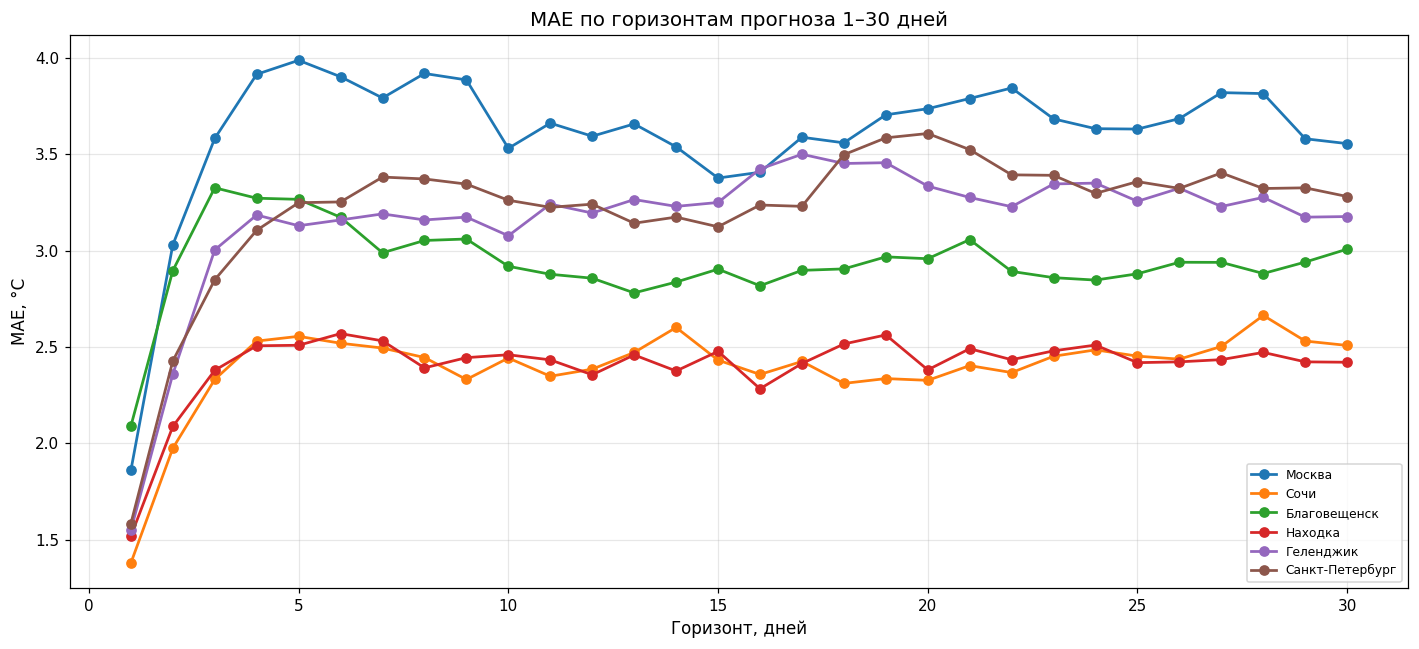

In [28]:
metrics_df = pd.DataFrame({
    city: {
        "MAE 1–30, °C": result["mae"],
        "RMSE 1–30, °C": result["rmse"],
        "MAPE 1–30, %": result["mape"],
        "WAPE 1–30, %": result["wape"],
        "MAE H=30, °C": result["mae_h30"],
        "RMSE H=30, °C": result["rmse_h30"],
        "MAPE H=30, %": result["mape_h30"],
        "WAPE H=30, %": result["wape_h30"],
    }
    for city, result in forecast_results.items()
}).T.round(3)

print("Метрики прогнозирования на тестовом периоде 2025:")
display(metrics_df)

if forecast_results:
    horizon_summary = pd.concat(
        [result["horizon_metrics"].assign(Город=city) for city, result in forecast_results.items()],
        ignore_index=True,
    )
    print("Метрики по каждому горизонту прогноза:")
    display(horizon_summary.head(20).round(3))

    fig, ax = plt.subplots(figsize=(13, 6))
    for city, result in forecast_results.items():
        ax.plot(result["horizon_metrics"]["horizon"], result["horizon_metrics"]["MAE"], marker="o", linewidth=1.8, label=city)
    ax.set_title("MAE по горизонтам прогноза 1–30 дней")
    ax.set_xlabel("Горизонт, дней")
    ax.set_ylabel("MAE, °C")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

**Интерпретация метрик прогнозирования:**

Для оценки прогноза используются MAE, RMSE, MAPE и WAPE. Основными метриками для температуры являются MAE, RMSE и WAPE, поскольку они устойчивее интерпретируются для значений температуры в градусах Цельсия. MAPE приведён в работе как обязательная метрика по заданию, однако для температуры он может давать завышенные значения: при температурах около нуля или при отрицательных значениях относительная процентная ошибка становится нестабильной. Поэтому при сравнении качества моделей основной акцент сделан на MAE, RMSE и WAPE.

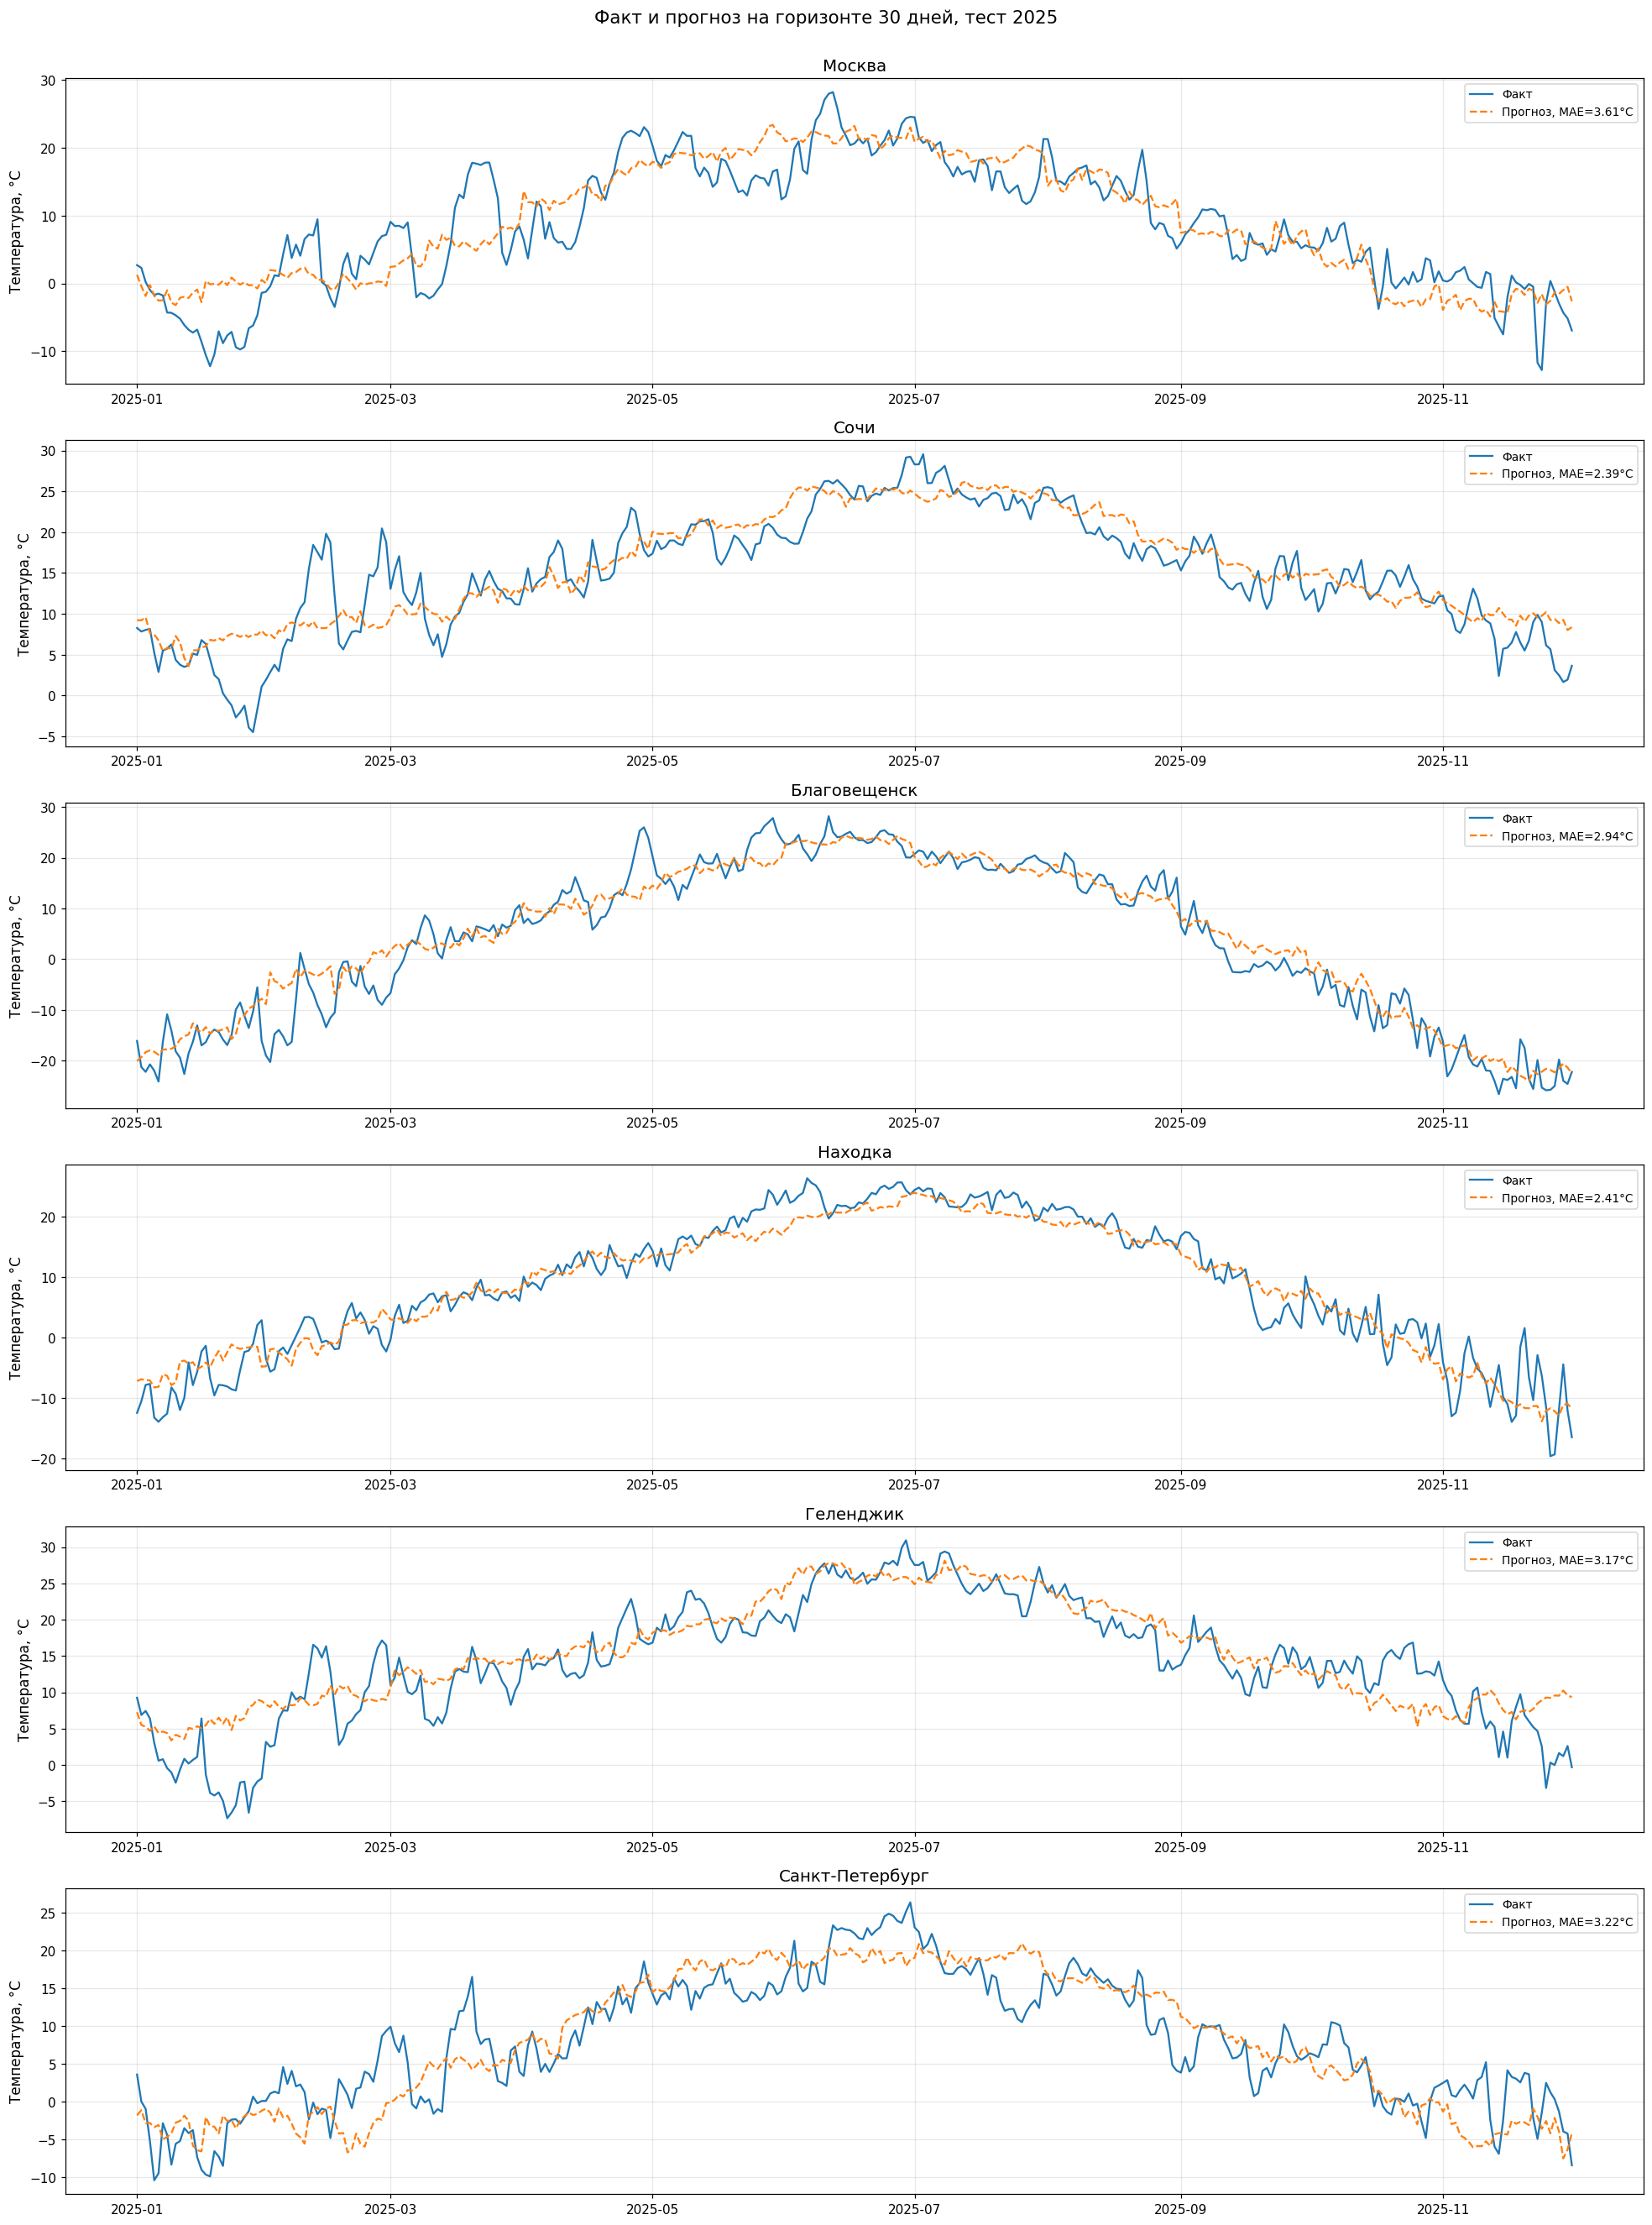

In [29]:
n = len(forecast_results)

if n > 0:
    fig, axes = plt.subplots(n, 1, figsize=(18, 4 * n))

    if n == 1:
        axes = [axes]

    for ax, (city, result) in zip(axes, forecast_results.items()):
        idx = result["idx_test"]
        y_true = result["y_test"].values
        y_pred = result["y_pred"]

        ax.plot(idx, y_true, label="Факт", linewidth=1.5)
        ax.plot(idx, y_pred, label=f"Прогноз, MAE={result['mae']:.2f}°C", linewidth=1.5, linestyle="--")
        ax.set_title(city)
        ax.set_ylabel("Температура, °C")
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

    plt.suptitle(f"Факт и прогноз на горизонте {HORIZON} дней, тест 2025", fontsize=14, y=1.002)
    plt.tight_layout()
    plt.show()
else:
    print("Нет обученных прогнозных моделей.")

In [30]:
residual_rows = []

def prepare_white_test_exog(result: dict, residuals: np.ndarray, max_features: int = 3) -> pd.DataFrame:
    exog = result["X_test"].copy()
    numeric_exog = exog.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan)
    numeric_exog = numeric_exog.dropna(axis=1, how="any")

    variable_cols = [col for col in numeric_exog.columns if numeric_exog[col].nunique(dropna=True) > 5 and numeric_exog[col].std() > 1e-12]
    numeric_exog = numeric_exog[variable_cols]

    if numeric_exog.empty:
        return pd.DataFrame({"prediction_h30": result["y_pred"]})

    residual_series = pd.Series(residuals, index=numeric_exog.index)
    correlations = numeric_exog.apply(lambda col: abs(col.corr(residual_series)))
    correlations = correlations.replace([np.inf, -np.inf], np.nan).dropna().sort_values(ascending=False)
    selected_cols = list(correlations.head(max_features).index)

    white_exog = numeric_exog[selected_cols].copy()
    white_exog["prediction_h30"] = result["y_pred"]
    white_exog = white_exog.loc[:, ~white_exog.columns.duplicated()]
    return white_exog


for city, result in forecast_results.items():
    residuals = result["y_test"].values - result["y_pred"]

    sample = residuals[:500] if len(residuals) > 500 else residuals
    shapiro_stat, shapiro_p = shapiro(sample)

    lb = acorr_ljungbox(residuals, lags=[10], return_df=True)
    lb_p = lb["lb_pvalue"].iloc[0]

    white_p = np.nan
    white_note = "не рассчитан"
    try:
        white_exog_df = prepare_white_test_exog(result, residuals, max_features=3)
        white_exog_df = white_exog_df.replace([np.inf, -np.inf], np.nan).dropna(axis=0)
        aligned_residuals = pd.Series(residuals, index=result["X_test"].index).loc[white_exog_df.index].to_numpy()

        if len(white_exog_df) > 30 and white_exog_df.shape[1] >= 1:
            white_exog = np.column_stack([np.ones(len(white_exog_df)), white_exog_df.to_numpy()])
            white_stat, white_lm_p, white_f_stat, white_f_p = het_white(aligned_residuals, white_exog)
            white_p = white_f_p
            white_note = "рассчитан"
        else:
            white_note = "недостаточно наблюдений/признаков"
    except Exception as exc:
        white_note = f"ошибка: {type(exc).__name__}"

    y_true_diff = np.diff(result["y_test"].values)
    y_pred_diff = np.diff(result["y_pred"])
    nonzero_mask = y_true_diff != 0
    if nonzero_mask.any():
        direction_accuracy = np.mean(np.sign(y_true_diff[nonzero_mask]) == np.sign(y_pred_diff[nonzero_mask]))
    else:
        direction_accuracy = np.nan

    residual_rows.append({
        "Город": city,
        "Среднее остатков": residuals.mean(),
        "Std остатков": residuals.std(),
        "Shapiro-Wilk p": shapiro_p,
        "Нормальность": "да" if shapiro_p > 0.05 else "нет",
        "Ljung-Box p": lb_p,
        "Есть автокорреляция": "да" if lb_p < 0.05 else "нет",
        "White p": white_p,
        "White status": white_note,
        "Есть гетероскедастичность": "да" if pd.notna(white_p) and white_p < 0.05 else "нет/не выявлена",
        "Direction accuracy": direction_accuracy,
    })

residual_df = pd.DataFrame(residual_rows).set_index("Город")

print("Анализ остатков и направления изменения температуры для горизонта 30 дней:")
display(residual_df.round(4))

print(
    "Пояснение: Direction accuracy около 0.5 означает, что модель слабо угадывает знак дневного изменения "
    "на горизонте 30 дней. Для месячного прогноза температуры это реалистичный результат и является "
    "аналитическим выводом, а не синтаксической ошибкой."
)


Анализ остатков и направления изменения температуры для горизонта 30 дней:


,Среднее остатков,Std остатков,Shapiro-Wilk p,Нормальность,Ljung-Box p,Есть автокорреляция,White p,White status,Есть гетероскедастичность,Direction accuracy
Город,,,,,,,,,,
Москва,-0.2370,4.4798,0.3824,да,0.0000,да,0.0077,рассчитан,да,0.4521
Сочи,-0.6025,3.3364,0.0000,нет,0.0000,да,0.0000,рассчитан,да,0.4970
Благовещенск,-0.7108,3.9314,0.0003,нет,0.0000,да,0.0000,рассчитан,да,0.5000
Находка,0.3655,3.1698,0.0003,нет,0.0000,да,0.0000,рассчитан,да,0.5090
Геленджик,-1.0355,4.0683,0.0008,нет,0.0000,да,0.0000,рассчитан,да,0.5240
Санкт-Петербург,0.1714,4.1408,0.0758,да,0.0000,да,0.0001,рассчитан,да,0.4940


Пояснение: Direction accuracy около 0.5 означает, что модель слабо угадывает знак дневного изменения на горизонте 30 дней. Для месячного прогноза температуры это реалистичный результат и является аналитическим выводом, а не синтаксической ошибкой.


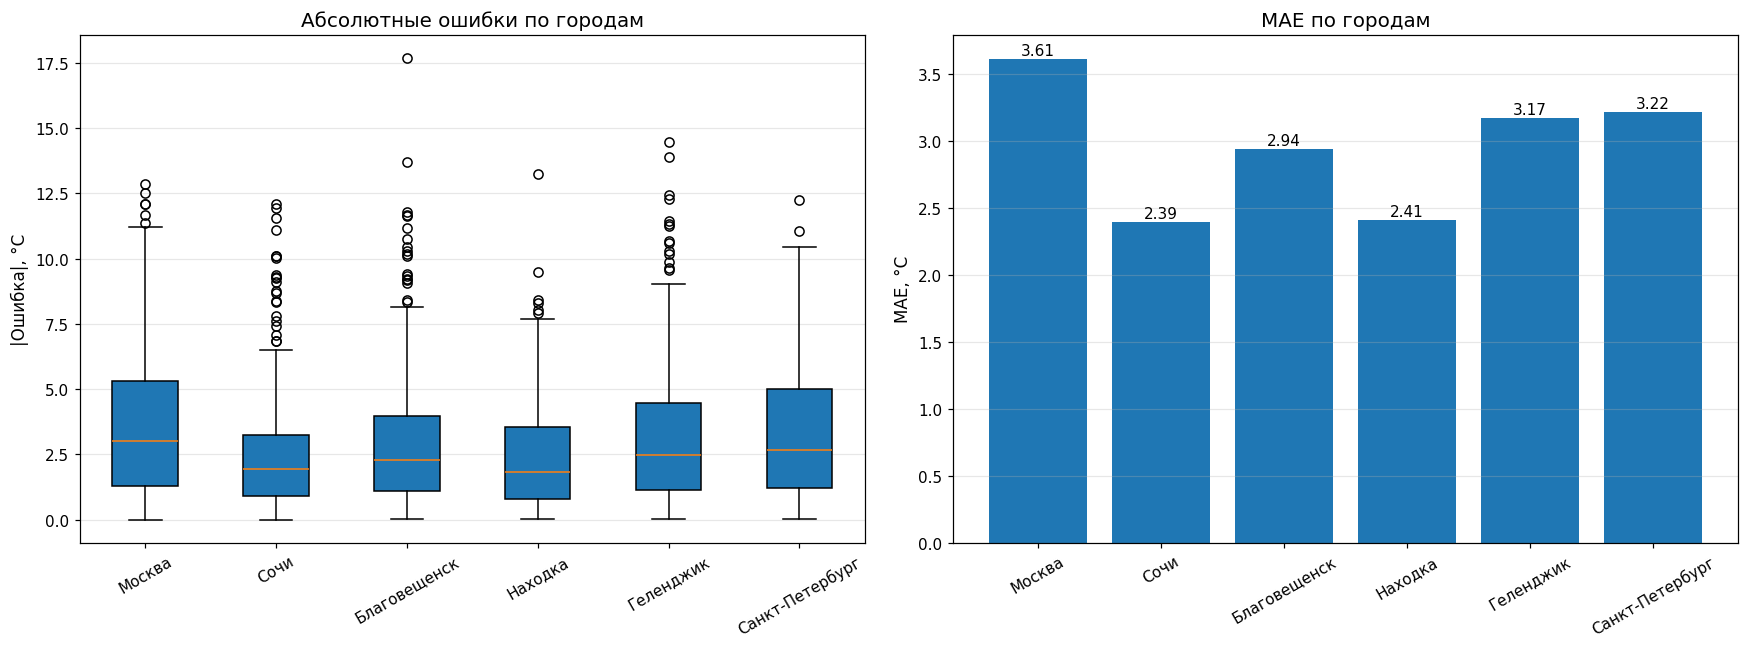

In [31]:
if forecast_results:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    abs_errors = {
        city: np.abs(result["y_test"].values - result["y_pred"])
        for city, result in forecast_results.items()
    }

    axes[0].boxplot(list(abs_errors.values()), labels=list(abs_errors.keys()), patch_artist=True)
    axes[0].set_title("Абсолютные ошибки по городам")
    axes[0].set_ylabel("|Ошибка|, °C")
    axes[0].tick_params(axis="x", rotation=30)
    axes[0].grid(axis="y", alpha=0.3)

    cities_for_plot = list(forecast_results.keys())
    mae_values = [forecast_results[city]["mae"] for city in cities_for_plot]

    bars = axes[1].bar(cities_for_plot, mae_values)
    axes[1].set_title("MAE по городам")
    axes[1].set_ylabel("MAE, °C")
    axes[1].tick_params(axis="x", rotation=30)
    axes[1].grid(axis="y", alpha=0.3)

    for bar, value in zip(bars, mae_values):
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.03,
            f"{value:.2f}",
            ha="center",
            fontsize=10,
        )

    plt.tight_layout()
    plt.show()
else:
    print("Нет результатов прогнозирования для визуализации.")

**Выводы по прогнозированию:**

- Отдельная модель для каждого города учитывает локальную климатическую специфику.
- Прогноз на горизонтах до 30 дней существенно сложнее краткосрочного прогноза, поэтому остатки могут сохранять автокорреляцию.
- На городах с более устойчивым температурным режимом ошибка обычно ниже, а на городах с резкой континентальностью или муссонным влиянием выше.

## 9. Единый двухэтапный конвейер

In [32]:
class WeatherPipeline:
    def __init__(
        self,
        classifier,
        label_encoder,
        classifier_input_kind,
        classification_channels,
        forecast_models,
        forecast_feature_columns_by_city,
        city_daily,
        climate_groups,
        window_days: int = 90,
        horizon: int = 30,
    ):
        self.classifier = classifier
        self.label_encoder = label_encoder
        self.classifier_input_kind = classifier_input_kind
        self.classification_channels = classification_channels
        self.forecast_models = forecast_models
        self.forecast_feature_columns_by_city = forecast_feature_columns_by_city
        self.city_daily = city_daily
        self.climate_groups = climate_groups
        self.window_days = window_days
        self.horizon = horizon

    def classify_climate(self, df: pd.DataFrame) -> tuple[str, float]:
        if len(df) < self.window_days:
            raise ValueError("Недостаточно данных для классификации.")

        window = df[self.classification_channels].iloc[-self.window_days:]

        if len(window) != self.window_days or window.isna().any().any():
            raise ValueError("Последнее окно классификации содержит пропуски или имеет неверную длину.")

        X_window = window.to_numpy(dtype=float).T[None, :, :]
        X_model = select_classifier_input(X_window, self.classifier_input_kind)

        pred_class = self.classifier.predict(X_model)[0]

        if hasattr(self.classifier, "predict_proba"):
            confidence = self.classifier.predict_proba(X_model)[0].max()
        else:
            confidence = np.nan

        climate_type = self.label_encoder.inverse_transform([pred_class])[0]
        return climate_type, confidence

    def select_city_within_climate(self, df: pd.DataFrame, climate_type: str) -> str:
        candidate_cities = [city for city, group in self.climate_groups.items() if group == climate_type and city in self.forecast_models]
        if not candidate_cities:
            raise ValueError(f"Нет прогнозной модели для типа климата: {climate_type}")

        current_profile = df[TARGET].iloc[-self.window_days:].to_numpy(dtype=float)
        current_profile = current_profile - np.nanmean(current_profile)

        distances = {}
        for city in candidate_cities:
            city_profile = self.city_daily[city][TARGET].iloc[-self.window_days:].to_numpy(dtype=float)
            city_profile = city_profile - np.nanmean(city_profile)
            distances[city] = np.nanmean((current_profile - city_profile) ** 2)

        return min(distances, key=distances.get)

    def forecast(self, df: pd.DataFrame, city: str) -> np.ndarray:
        if city not in self.forecast_models:
            raise ValueError(f"Нет прогнозной модели для города: {city}")

        X, _, _, feature_columns, _ = build_forecast_dataset(df, horizons=FORECAST_HORIZONS)
        expected_columns = self.forecast_feature_columns_by_city[city]
        X = X.reindex(columns=expected_columns, fill_value=0)

        if len(X) == 0:
            raise ValueError("Недостаточно данных для прогноза.")

        model = self.forecast_models[city]
        return model.predict(X.iloc[[-1]])[0]

    def run(self, df: pd.DataFrame, verbose: bool = True) -> dict:
        climate_type, confidence = self.classify_climate(df)
        selected_city = self.select_city_within_climate(df, climate_type)
        forecast_values = self.forecast(df, selected_city)

        result = {
            "predicted_climate_type": climate_type,
            "selected_forecast_city": selected_city,
            "confidence": confidence,
            "forecast_temperature_next_30_days": forecast_values,
            "forecast_temperature_after_30_days": float(forecast_values[self.horizon - 1]),
        }

        if verbose:
            confidence_text = "не рассчитана" if np.isnan(confidence) else f"{confidence:.1%}"
            print(f"Определён тип климата: {climate_type}, уверенность: {confidence_text}")
            print(f"Выбрана прогнозная модель города: {selected_city}")
            print(f"Прогноз температуры через {self.horizon} дней: {result['forecast_temperature_after_30_days']:.1f}°C")

        return result


weather_pipeline = WeatherPipeline(
    classifier=best_model,
    label_encoder=label_encoder,
    classifier_input_kind=best_model_input_kind,
    classification_channels=classification_channels,
    forecast_models=forecast_models,
    forecast_feature_columns_by_city=forecast_feature_columns_by_city,
    city_daily=city_daily,
    climate_groups=CLIMATE_GROUPS,
    window_days=CLASSIFICATION_WINDOW_DAYS,
    horizon=HORIZON,
)

print("Двухэтапный конвейер создан: классификация типа климата → выбор городской прогнозной модели → прогноз 1–30 дней.")

Двухэтапный конвейер создан: классификация типа климата → выбор городской прогнозной модели → прогноз 1–30 дней.


In [33]:
print("=" * 110)
print(f"{'Город':<22} {'Истинный тип':<28} {'Предсказанный тип':<28} {'Модель города':<22} {'H=30':>10}")
print("=" * 110)

for city, df in city_daily.items():
    try:
        result = weather_pipeline.run(df, verbose=False)
        print(
            f"{city:<22} "
            f"{CLIMATE_GROUPS[city]:<28} "
            f"{result['predicted_climate_type']:<28} "
            f"{result['selected_forecast_city']:<22} "
            f"{result['forecast_temperature_after_30_days']:>8.1f}°C"
        )

    except Exception as exc:
        print(f"{city:<22} ошибка: {exc}")

print("=" * 110)

Город                  Истинный тип                 Предсказанный тип            Модель города                H=30
Москва                 умеренно-континентальный     умеренно-континентальный     Москва                     -2.6°C
Сочи                   черноморский                 черноморский                 Сочи                        8.4°C
Благовещенск           дальневосточный              дальневосточный              Благовещенск              -22.6°C
Находка                дальневосточный              дальневосточный              Находка                   -11.8°C
Геленджик              черноморский                 черноморский                 Геленджик                   9.3°C
Санкт-Петербург        умеренно-континентальный     умеренно-континентальный     Санкт-Петербург            -4.1°C


## 10. Итоговая интерпретация

In [34]:
classification_f1 = classification_report(
    y_test_labels,
    y_pred_labels,
    output_dict=True,
    zero_division=0,
)["macro avg"]["f1-score"]

print("=" * 90)
print("ИТОГОВАЯ СВОДКА")
print("=" * 90)

print()
print(f"Этап 1. Классификация типа климата по временным рядам, модель: {best_name}")
print(f"Окно классификации: {CLASSIFICATION_WINDOW_DAYS} дней")
print(f"Каналы временного ряда: {', '.join(classification_channels)}")
print(f"Accuracy: {classification_accuracy:.4f}")
print(f"F1-macro: {classification_f1:.4f}")

if not np.isnan(roc_auc_macro):
    print(f"ROC-AUC macro: {roc_auc_macro:.4f}")

print()
print(f"Этап 2. Прогнозирование, модель: {forecast_model_name}")
print(f"Горизонты прогноза: 1–{HORIZON} дней")
print()

if forecast_results:
    print(f"{'Город':<22} {'MAE 1–30':>10} {'RMSE 1–30':>12} {'MAPE 1–30':>12} {'WAPE 1–30':>12} {'MAE H=30':>10}")
    print("-" * 84)

    for city, result in forecast_results.items():
        print(
            f"{city:<22} "
            f"{result['mae']:>9.2f}°C "
            f"{result['rmse']:>11.2f}°C "
            f"{result['mape']:>11.2f}% "
            f"{result['wape']:>11.2f}% "
            f"{result['mae_h30']:>9.2f}°C"
        )

print("=" * 90)

print("""
Основной вывод:
двухэтапный подход «классификация типа климата по временному ряду →
выбор специализированной городской прогнозной модели» применим для данной задачи. Первый этап
реализован именно как классификация временных рядов: объектом является 90-дневное
многомерное окно метеонаблюдений, а не строка агрегированных табличных признаков.

Ограничения:
1. Данные за 2019–2025 дают ограниченную историю для долгосрочного прогноза.
2. Модель строит прогноз на горизонтах 1–30 дней, однако это статистический среднесрочный прогноз, а не полноценная физическая синоптическая модель.
3. Для промышленного применения желательно добавить доверительные интервалы,
   ансамбль моделей и сравнение с базовыми моделями: seasonal naive и SARIMA.
""")

ИТОГОВАЯ СВОДКА

Этап 1. Классификация типа климата по временным рядам, модель: ROCKET_multivariate
Окно классификации: 90 дней
Каналы временного ряда: temperature_2m, relative_humidity_2m, precipitation, rain, snowfall, weathercode, wind_speed_10m, surface_pressure
Accuracy: 0.8889
F1-macro: 0.8878
ROC-AUC macro: 0.9167

Этап 2. Прогнозирование, модель: LightGBM
Горизонты прогноза: 1–30 дней

Город                    MAE 1–30    RMSE 1–30    MAPE 1–30    WAPE 1–30   MAE H=30
------------------------------------------------------------------------------------
Москва                      3.61°C        4.47°C      207.86%       35.03%      3.56°C
Сочи                        2.39°C        3.18°C       39.65%       15.70%      2.51°C
Благовещенск                2.94°C        3.86°C       57.77%       21.12%      3.01°C
Находка                     2.41°C        3.06°C       76.30%       20.53%      2.42°C
Геленджик                   3.17°C        4.11°C      122.50%       21.16%      3.18°C

## Краткие выводы для отчёта

1. Выполнена загрузка и предварительная обработка метеоданных шести городов России за 2019–2025 годы.
2. Почасовые данные приведены к суточной частоте; пропуски обработаны интерполяцией по времени с последующим прямым/обратным заполнением.
3. Проведён разведочный анализ: временные ряды, распределения, Q-Q plots, сезонные профили, корреляции, декомпозиция и ADF-тест стационарности.
4. Построены временные, циклические, лаговые, скользящие, динамические и агрегированные признаки; выполнена PCA-визуализация разделимости климатических групп.
5. Классификационный этап решает задачу определения типа климата, а не только города. Для каждого типа климата используется минимум два города.
6. Качество классификации оценено по Accuracy, Precision, Recall, F1-score, confusion matrix, ROC-AUC One-vs-Rest, ошибкам по сезонам/месяцам/годам, permutation importance и групповой важности исходных метеопараметров.
7. Для каждого города построена отдельная прогнозная модель температуры на горизонтах 1–30 дней.
8. Качество прогноза оценено по MAE, RMSE, MAPE, WAPE, accuracy направления изменения, а также по остаткам: Shapiro-Wilk, Ljung-Box и White test.
9. Итоговый конвейер объединяет два этапа: классификацию климатического типа, выбор подходящей городской прогнозной модели и выдачу прогноза на месяц вперёд.
10. Основное ограничение решения — статистический характер прогноза и ограниченная длина исторического ряда; для промышленного применения желательно добавить ансамбли, доверительные интервалы и сравнение с физическими метеомоделями.